In [23]:
print('test')

test


### 데이터 전처리

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone

import os
import random
import joblib
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    CSVLogger
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [16]:
df = pd.read_csv('./dataset/hotel_booking.csv', encoding='utf-8')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [17]:
df2 = df.copy()

In [18]:
# children의 결측치는 0으로 처리 후 정수형으로 바꿈
df2["children"] = df2["children"].fillna(0).astype(int)

# 투숙객 0명 값 제거
df2 = df2[
    (df2["adults"] + df2["children"] + df2["babies"]) > 0
]

print("제거 후 데이터 크기:", df2.shape)

# children / babies 극단값 제거
df2 = df2[
    (df2["children"] < 5) &
    (df2["babies"] < 5)
]

print("제거 후 데이터 크기:", df2.shape)

# adr 이상치 처리
df2 = df2[
    (df2["adr"] >= 0)
    & (df2["adr"] <= 1000)
]

# 파생변수 : 성인+아동+영아 -> 투숙객 수 
df2["total_guests"] = (
    df2["adults"]
    + df2["children"]
    + df2["babies"]
)

# 파생변수 : 아이 동반
df2["has_children"] = (
    (df2["children"] + df2["babies"]) > 0
).astype(int)

# 원본 제거
df2 = df2.drop(columns=["adults", "children", "babies"])

# agent / company는 ID 대신 이용 여부 변수 생성
df2["has_agent"] = df2["agent"].notna().astype(int)
df2["has_company"] = df2["company"].notna().astype(int)

# 원본 제거
df2 = df2.drop(columns=["agent", "company"])

# 총 숙박일수
df2["total_nights"] = (
    df2["stays_in_weekend_nights"]
    + df2["stays_in_week_nights"]
)

# 주말 포함 여부
df2["has_weekend_stay"] = (
    df2["stays_in_weekend_nights"] > 0
).astype(int)

# 숙박일수 0 제거 및 관련 컬럼 삭제
df2 = df2[df2["total_nights"] > 0]
print("0박 예약 제거 후 데이터 크기:", df2.shape)

df2 = df2.drop(
    columns=[
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "has_weekend_stay"
    ]
)

print("남은 0박 예약:", (df2["total_nights"] == 0).sum())

# 파생컬럼 : 예약 대기시간 유무
df2["has_waiting_list"] = (df2["days_in_waiting_list"] > 0).astype(int)

# 관련 컬럼 삭제
df2 = df2.drop(
    columns=["days_in_waiting_list"]
)

# country 결측치 처리 : unknown
df2["country"] = df2["country"].fillna("Unknown")

# 178개국 -> 상위 10개 + other 로 정리
top_countries = (
    df2["country"]
    .value_counts()
    .head(10)
    .index
)

df2["country_group"] = df2["country"].where(
    df2["country"].isin(top_countries),
    "Other"
)

# 관련 컬럼 삭제
df2 = df2.drop(columns=["country"])

# 제거해야 할 컬럼
drop_cols=['name', 'email', 'phone-number', 'credit_card', 
           'reservation_status', 'reservation_status_date', 'assigned_room_type',
           'arrival_date_day_of_month', 'arrival_date_week_number',
           'arrival_date_year', 'booking_changes', 'distribution_channel', 'deposit_type']

df2 = df2.drop(columns=drop_cols)

print("데이터 크기:", df2.shape)
print("컬럼명:", df2.columns)

제거 후 데이터 크기: (119210, 36)
제거 후 데이터 크기: (119207, 36)
0박 예약 제거 후 데이터 크기: (118560, 37)
남은 0박 예약: 0
데이터 크기: (118560, 21)
컬럼명: Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_month', 'meal',
       'market_segment', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type', 'customer_type',
       'adr', 'required_car_parking_spaces', 'total_of_special_requests',
       'total_guests', 'has_children', 'has_agent', 'has_company',
       'total_nights', 'has_waiting_list', 'country_group'],
      dtype='str')


### 모델 학습

In [19]:
categorical_cols = [
    "hotel",
    "arrival_date_month",
    "meal",
    "market_segment",
    "reserved_room_type",
    "customer_type",
    "country_group"
]

numeric_cols = [
    "lead_time",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "has_agent",
    "has_company",
    "total_guests",
    "total_nights",
    "has_waiting_list",
    "has_children"
]

feature_cols = categorical_cols + numeric_cols

X = df2[feature_cols]
y = df2["is_canceled"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
categorical_transformer = Pipeline([
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [22]:
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [32]:
preprocessor_dl = clone(preprocessor)

X_subtrain_dl = preprocessor_dl.fit_transform(
    X_subtrain
).astype("float32")

X_val_dl = preprocessor_dl.transform(
    X_val
).astype("float32")

X_test_dl = preprocessor_dl.transform(
    X_test
).astype("float32")

y_subtrain_dl = y_subtrain.to_numpy(
    dtype="float32"
)

y_val_dl = y_val.to_numpy(
    dtype="float32"
)

y_test_dl = y_test.to_numpy(
    dtype="float32"
)

print("Sub-train:", X_subtrain_dl.shape)
print("Validation:", X_val_dl.shape)
print("Test:", X_test_dl.shape)

Sub-train: (75878, 64)
Validation: (18970, 64)
Test: (23712, 64)


In [33]:
os.makedirs("model_dl", exist_ok=True)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

model = Sequential([
    Input(shape=(X_subtrain_dl.shape[1],)),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.AUC(
            name="roc_auc"
        ),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,457 (76.00 KB)

 Trainable params: 19,073 (74.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [34]:
callbacks = [
    ModelCheckpoint(
        "model_dl/mlp_baseline_best.keras",
        monitor="val_roc_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_roc_auc",
        mode="max",
        patience=12,
        min_delta=0.0002,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    ),

    CSVLogger(
        "model_dl/mlp_baseline_log.csv"
    )
]

In [35]:
joblib.dump(
    preprocessor_dl,
    "model_dl/mlp_baseline_preprocessor.joblib"
)

start_time = time.perf_counter()

history = model.fit(
    X_subtrain_dl,
    y_subtrain_dl,
    validation_data=(
        X_val_dl,
        y_val_dl
    ),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

baseline_training_time = (
    time.perf_counter() - start_time
)

print(
    f"MLP Baseline 학습 시간: "
    f"{baseline_training_time / 60:.2f}분"
)

Epoch 1/100
285/297 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7763 - loss: 0.4554 - precision: 0.7144 - recall: 0.6649 - roc_auc: 0.8509
Epoch 1: val_roc_auc improved from None to 0.90255, saving model to model_dl/mlp_baseline_best.keras

Epoch 1: finished saving model to model_dl/mlp_baseline_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7772 - loss: 0.4531 - precision: 0.7169 - recall: 0.6646 - roc_auc: 0.8523 - val_accuracy: 0.8220 - val_loss: 0.3739 - val_precision: 0.8170 - val_recall: 0.6729 - val_roc_auc: 0.9025 - learning_rate: 0.0010
Epoch 2/100
290/297 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8175 - loss: 0.3785 - precision: 0.7904 - recall: 0.6943 - roc_auc: 0.8970
Epoch 2: val_roc_auc improved from 0.90255 to 0.91166, saving model to model_dl/mlp_baseline_best.keras

Epoch 2: finished saving model to model_dl/mlp_baseline_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8175 - loss: 0.3783 - precision: 0.7906 - recall: 0.6940 

KeyboardInterrupt: 

In [ ]:
# 학습 기록 확인
log_df = pd.read_csv(
    "model_dl/mlp_baseline_log.csv"
)

best_index = log_df["val_roc_auc"].idxmax()
best_epoch = int(log_df.loc[best_index, "epoch"]) + 1

print("전체 학습 Epoch:", len(log_df))
print("최고 성능 Epoch:", best_epoch)
print(
    "최고 Validation ROC-AUC:",
    round(log_df.loc[best_index, "val_roc_auc"], 4)
)

# 최고 모델 불러오기
best_mlp = tf.keras.models.load_model(
    "model_dl/mlp_baseline_best.keras"
)

# 검증 데이터 예측
val_proba = best_mlp.predict(
    X_val_dl,
    batch_size=1024
).ravel()

val_pred = (
    val_proba >= 0.5
).astype(int)

print("\nValidation Accuracy :",
      round(accuracy_score(y_val_dl, val_pred), 4))

print("Validation Precision:",
      round(precision_score(y_val_dl, val_pred), 4))

print("Validation Recall   :",
      round(recall_score(y_val_dl, val_pred), 4))

print("Validation F1       :",
      round(f1_score(y_val_dl, val_pred), 4))

print("Validation ROC-AUC  :",
      round(roc_auc_score(y_val_dl, val_proba), 4))

print("\nConfusion Matrix")
print(confusion_matrix(y_val_dl, val_pred))

if "baseline_training_time" in globals():
    print(
        "\n학습 시간:",
        round(baseline_training_time / 60, 2),
        "분"
    )

전체 학습 Epoch: 59
최고 성능 Epoch: 55
최고 Validation ROC-AUC: 0.9358
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Validation Accuracy : 0.8562
Validation Precision: 0.8166
Validation Recall   : 0.7919
Validation F1       : 0.8041
Validation ROC-AUC  : 0.9359

Confusion Matrix
[[10645  1257]
 [ 1471  5597]]

학습 시간: 1.21 분


In [ ]:
import os
import gc
import json
import time
import itertools
import random

import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

SEARCH_DIR = "model_dl/search"
RESULT_PATH = f"{SEARCH_DIR}/mlp_search_results.csv"
BEST_MODEL_PATH = f"{SEARCH_DIR}/mlp_search_best.keras"
BEST_CONFIG_PATH = f"{SEARCH_DIR}/mlp_search_best_config.json"

os.makedirs(SEARCH_DIR, exist_ok=True)

# 전처리기는 모든 탐색 모델에서 동일하게 사용
joblib.dump(
    preprocessor_dl,
    f"{SEARCH_DIR}/mlp_search_preprocessor.joblib"
)

# 탐색할 조건
architectures = [
    [64, 32],
    [128, 64],
    [128, 64, 32],
    [256, 128, 64],
    [256, 128, 64, 32]
]

dropout_rates = [0.1, 0.2, 0.3, 0.4]
l2_rates = [0.0, 0.00001, 0.0001, 0.0005]
learning_rates = [0.001, 0.0005, 0.00025]
batch_sizes = [128, 256, 512]
batch_norm_options = [True, False]

# 전체 조합 생성
all_configs = []

for values in itertools.product(
    architectures,
    dropout_rates,
    l2_rates,
    learning_rates,
    batch_sizes,
    batch_norm_options
):
    units, dropout, l2_rate, lr, batch_size, batch_norm = values

    config = {
        "units": units,
        "dropout": dropout,
        "l2": l2_rate,
        "learning_rate": lr,
        "batch_size": batch_size,
        "batch_norm": batch_norm
    }

    config["config_key"] = json.dumps(
        config,
        sort_keys=True
    )

    all_configs.append(config)

# 실행 순서 고정
search_random = random.Random(42)
search_random.shuffle(all_configs)

# 우선 2개만 시험
MAX_EXPERIMENTS = 240
selected_configs = all_configs[:MAX_EXPERIMENTS]

In [ ]:
def build_search_mlp(config):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    regularizer = None

    if config["l2"] > 0:
        regularizer = tf.keras.regularizers.l2(
            config["l2"]
        )

    search_model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(X_subtrain_dl.shape[1],)
        )
    ])

    for units in config["units"]:
        search_model.add(
            tf.keras.layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=regularizer
            )
        )

        if config["batch_norm"]:
            search_model.add(
                tf.keras.layers.BatchNormalization()
            )

        search_model.add(
            tf.keras.layers.Dropout(
                config["dropout"]
            )
        )

    search_model.add(
        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    search_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=config["learning_rate"]
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.AUC(
                name="roc_auc"
            )
        ]
    )

    return search_model

In [ ]:
if os.path.exists(RESULT_PATH):
    search_results = pd.read_csv(RESULT_PATH)
else:
    search_results = pd.DataFrame()

if not search_results.empty:
    completed_keys = set(
        search_results.loc[
            search_results["status"] == "ok",
            "config_key"
        ]
    )

    successful_results = search_results[
        search_results["status"] == "ok"
    ]

    if len(successful_results) > 0:
        global_best_auc = (
            successful_results["val_roc_auc"].max()
        )
    else:
        global_best_auc = -np.inf
else:
    completed_keys = set()
    global_best_auc = -np.inf

for experiment_number, config in enumerate(
    selected_configs,
    start=1
):
    if config["config_key"] in completed_keys:
        print(
            f"[{experiment_number}/{MAX_EXPERIMENTS}] "
            "이미 완료된 조건: 건너뜀"
        )
        continue

    print(
        f"\n[{experiment_number}/{MAX_EXPERIMENTS}] "
        f"실험 시작: {config}"
    )

    start = time.perf_counter()

    try:
        search_model = build_search_mlp(config)

        search_callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_roc_auc",
                mode="max",
                patience=8,
                min_delta=0,
                restore_best_weights=True,
                verbose=0
            ),

            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                mode="min",
                factor=0.5,
                patience=4,
                min_lr=0.00001,
                verbose=0
            )
        ]

        search_history = search_model.fit(
            X_subtrain_dl,
            y_subtrain_dl,
            validation_data=(
                X_val_dl,
                y_val_dl
            ),
            epochs=80,
            batch_size=config["batch_size"],
            callbacks=search_callbacks,
            verbose=0
        )

        val_probability = search_model.predict(
            X_val_dl,
            batch_size=2048,
            verbose=0
        ).ravel()

        val_prediction = (
            val_probability >= 0.5
        ).astype(int)

        val_auc = roc_auc_score(
            y_val_dl,
            val_probability
        )

        best_epoch = (
            np.argmax(
                search_history.history["val_roc_auc"]
            ) + 1
        )

        elapsed_seconds = (
            time.perf_counter() - start
        )

        result = {
            "status": "ok",
            "config_key": config["config_key"],
            "units": "-".join(
                map(str, config["units"])
            ),
            "dropout": config["dropout"],
            "l2": config["l2"],
            "learning_rate": config["learning_rate"],
            "batch_size": config["batch_size"],
            "batch_norm": config["batch_norm"],
            "epochs_run": len(
                search_history.history["loss"]
            ),
            "best_epoch": best_epoch,
            "training_seconds": elapsed_seconds,
            "val_accuracy": accuracy_score(
                y_val_dl,
                val_prediction
            ),
            "val_precision": precision_score(
                y_val_dl,
                val_prediction
            ),
            "val_recall": recall_score(
                y_val_dl,
                val_prediction
            ),
            "val_f1": f1_score(
                y_val_dl,
                val_prediction
            ),
            "val_roc_auc": val_auc,
            "error": ""
        }

        # 기존 결과에 한 줄 추가 후 즉시 저장
        search_results = pd.concat(
            [
                search_results,
                pd.DataFrame([result])
            ],
            ignore_index=True
        )

        search_results.to_csv(
            RESULT_PATH,
            index=False,
            encoding="utf-8-sig"
        )

        # 지금까지 최고 모델이면 별도 저장
        if val_auc > global_best_auc:
            global_best_auc = val_auc

            search_model.save(
                BEST_MODEL_PATH
            )

            with open(
                BEST_CONFIG_PATH,
                "w",
                encoding="utf-8"
            ) as file:
                json.dump(
                    config,
                    file,
                    ensure_ascii=False,
                    indent=2
                )

            print(
                f"새 최고 모델 저장: "
                f"ROC-AUC {val_auc:.6f}"
            )

        print(
            f"실험 완료 | "
            f"ROC-AUC: {val_auc:.6f} | "
            f"소요시간: {elapsed_seconds / 60:.2f}분"
        )

    except Exception as error:
        elapsed_seconds = (
            time.perf_counter() - start
        )

        error_result = {
            "status": "error",
            "config_key": config["config_key"],
            "units": "-".join(
                map(str, config["units"])
            ),
            "dropout": config["dropout"],
            "l2": config["l2"],
            "learning_rate": config["learning_rate"],
            "batch_size": config["batch_size"],
            "batch_norm": config["batch_norm"],
            "training_seconds": elapsed_seconds,
            "error": str(error)
        }

        search_results = pd.concat(
            [
                search_results,
                pd.DataFrame([error_result])
            ],
            ignore_index=True
        )

        search_results.to_csv(
            RESULT_PATH,
            index=False,
            encoding="utf-8-sig"
        )

        print("실험 오류:", error)

    finally:
        if "search_model" in locals():
            del search_model

        if "search_history" in locals():
            del search_history

        tf.keras.backend.clear_session()
        gc.collect()

[1/240] 이미 완료된 조건: 건너뜀
[2/240] 이미 완료된 조건: 건너뜀

[3/240] 실험 시작: {'units': [256, 128, 64], 'dropout': 0.1, 'l2': 1e-05, 'learning_rate': 0.0005, 'batch_size': 128, 'batch_norm': False, 'config_key': '{"batch_norm": false, "batch_size": 128, "dropout": 0.1, "l2": 1e-05, "learning_rate": 0.0005, "units": [256, 128, 64]}'}
새 최고 모델 저장: ROC-AUC 0.935741
실험 완료 | ROC-AUC: 0.935741 | 소요시간: 1.35분

[4/240] 실험 시작: {'units': [128, 64, 32], 'dropout': 0.3, 'l2': 0.0, 'learning_rate': 0.001, 'batch_size': 128, 'batch_norm': False, 'config_key': '{"batch_norm": false, "batch_size": 128, "dropout": 0.3, "l2": 0.0, "learning_rate": 0.001, "units": [128, 64, 32]}'}
실험 완료 | ROC-AUC: 0.934493 | 소요시간: 1.16분

[5/240] 실험 시작: {'units': [128, 64, 32], 'dropout': 0.1, 'l2': 0.0, 'learning_rate': 0.0005, 'batch_size': 256, 'batch_norm': False, 'config_key': '{"batch_norm": false, "batch_size": 256, "dropout": 0.1, "l2": 0.0, "learning_rate": 0.0005, "units": [128, 64, 32]}'}
실험 완료 | ROC-AUC: 0.934496 | 소요시간: 1.05분


In [ ]:
results = pd.read_csv(
    "model_dl/search/mlp_search_results.csv"
)

successful = results[
    results["status"] == "ok"
].copy()

errors = results[
    results["status"] == "error"
].copy()

print("전체 기록 수:", len(results))
print("정상 완료:", len(successful))
print("오류 발생:", len(errors))

top10 = (
    successful
    .sort_values(
        "val_roc_auc",
        ascending=False
    )
    .head(10)
)

display(
    top10[
        [
            "units",
            "dropout",
            "l2",
            "learning_rate",
            "batch_size",
            "batch_norm",
            "epochs_run",
            "best_epoch",
            "training_seconds",
            "val_accuracy",
            "val_precision",
            "val_recall",
            "val_f1",
            "val_roc_auc"
        ]
    ]
)

print("\n탐색 최고 Validation ROC-AUC:")
print(top10.iloc[0]["val_roc_auc"])

print("\n탐색 최고 설정:")
print(top10.iloc[0]["config_key"])

if len(errors) > 0:
    print("\n오류 내용:")
    display(
        errors[
            [
                "units",
                "dropout",
                "learning_rate",
                "batch_size",
                "error"
            ]
        ].head(10)
    )

전체 기록 수: 240
정상 완료: 240
오류 발생: 0


,units,dropout,l2,learning_rate,batch_size,batch_norm,epochs_run,best_epoch,training_seconds,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
136,256-128-64,0.3,0.00001,0.00100,512,False,64,56,49.462505,0.859726,0.829126,0.785371,0.806656,0.937796
112,256-128-64,0.3,0.00010,0.00050,512,True,80,80,83.180409,0.858355,0.810577,0.808857,0.809716,0.937732
23,256-128-64,0.4,0.00001,0.00050,256,True,80,76,129.970908,0.858566,0.810421,0.809847,0.810134,0.937695
119,256-128-64,0.4,0.00050,0.00050,512,True,80,77,81.306438,0.857565,0.820182,0.791171,0.805416,0.937567
188,256-128-64,0.4,0.00010,0.00100,512,False,79,71,63.489769,0.859041,0.826352,0.787068,0.806232,0.937554
58,256-128-64,0.4,0.00000,0.00100,512,False,76,68,56.225021,0.859989,0.830338,0.784522,0.806780,0.937484
167,256-128-64,0.4,0.00010,0.00100,128,False,67,59,132.788554,0.860200,0.822054,0.797397,0.809537,0.937250
61,256-128-64-32,0.4,0.00000,0.00100,512,True,69,61,73.513589,0.856721,0.797212,0.825410,0.811066,0.937244
221,256-128-64-32,0.3,0.00010,0.00025,128,True,75,67,217.477664,0.859884,0.811089,0.813384,0.812235,0.937220
69,256-128-64-32,0.4,0.00050,0.00025,128,True,76,68,187.858997,0.855509,0.795600,0.823854,0.809481,0.937204



탐색 최고 Validation ROC-AUC:
0.9377959583057904

탐색 최고 설정:
{"batch_norm": false, "batch_size": 512, "dropout": 0.3, "l2": 1e-05, "learning_rate": 0.001, "units": [256, 128, 64]}


In [36]:
FOCUSED_DIR = "model_dl/focused"

FOCUSED_RESULT_PATH = (
    f"{FOCUSED_DIR}/focused_search_results.csv"
)

FOCUSED_BEST_MODEL_PATH = (
    f"{FOCUSED_DIR}/focused_best.keras"
)

FOCUSED_BEST_CONFIG_PATH = (
    f"{FOCUSED_DIR}/focused_best_config.json"
)

os.makedirs(
    FOCUSED_DIR,
    exist_ok=True
)

joblib.dump(
    preprocessor_dl,
    f"{FOCUSED_DIR}/focused_preprocessor.joblib"
)

# 기존 최고 구조 + 너비 확장 구조
focused_architectures = [
    [256, 128, 64],       # 기존 최고 구조
    [384, 192, 96],
    [512, 256, 128],
    [512, 256, 128, 64],
    [512, 512, 256, 128]
]

# 옵티마이저별 적합한 학습률
optimizer_configs = [
    {
        "optimizer": "Adam",
        "learning_rate": 0.001
    },
    {
        "optimizer": "Adam",
        "learning_rate": 0.0005
    },
    {
        "optimizer": "AdamW",
        "learning_rate": 0.001
    },
    {
        "optimizer": "AdamW",
        "learning_rate": 0.0005
    },
    {
        "optimizer": "Nadam",
        "learning_rate": 0.001
    },
    {
        "optimizer": "Nadam",
        "learning_rate": 0.0005
    },
    {
        "optimizer": "RMSprop",
        "learning_rate": 0.001
    },
    {
        "optimizer": "RMSprop",
        "learning_rate": 0.0005
    },
    {
        "optimizer": "SGD",
        "learning_rate": 0.01
    },
    {
        "optimizer": "SGD",
        "learning_rate": 0.005
    }
]

focused_configs = []

for architecture in focused_architectures:
    for optimizer_config in optimizer_configs:
        config = {
            "units": architecture,
            "optimizer": optimizer_config["optimizer"],
            "learning_rate": optimizer_config[
                "learning_rate"
            ],
            "dropout": 0.3,
            "l2": 0.00001,
            "batch_size": 512,
            "batch_norm": False,
            "activation": "relu"
        }

        config["config_key"] = json.dumps(
            config,
            sort_keys=True
        )

        focused_configs.append(config)

print("집중 탐색 모델 수:", len(focused_configs))

집중 탐색 모델 수: 50


In [37]:
def create_optimizer(
    optimizer_name,
    learning_rate
):
    if optimizer_name == "Adam":
        return tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer_name == "AdamW":
        return tf.keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=0.00001
        )

    elif optimizer_name == "Nadam":
        return tf.keras.optimizers.Nadam(
            learning_rate=learning_rate
        )

    elif optimizer_name == "RMSprop":
        return tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    elif optimizer_name == "SGD":
        return tf.keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9,
            nesterov=True
        )

    else:
        raise ValueError(
            f"지원하지 않는 옵티마이저: "
            f"{optimizer_name}"
        )

In [ ]:
def build_focused_mlp(
    config,
    seed=42
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    regularizer = tf.keras.regularizers.l2(
        config["l2"]
    )

    focused_model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(X_subtrain_dl.shape[1],)
        )
    ])

    for units in config["units"]:
        focused_model.add(
            tf.keras.layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=regularizer
            )
        )

        focused_model.add(
            tf.keras.layers.Dropout(
                config["dropout"]
            )
        )

    focused_model.add(
        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    optimizer = create_optimizer(
        config["optimizer"],
        config["learning_rate"]
    )

    focused_model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.AUC(
                name="roc_auc"
            )
        ]
    )

    return focused_model

In [39]:
required_names = [
    "X_subtrain_dl",
    "y_subtrain_dl",
    "X_val_dl",
    "y_val_dl",
    "build_focused_mlp"
]

missing_names = [
    name
    for name in required_names
    if name not in globals()
]

if missing_names:
    raise RuntimeError(
        f"먼저 실행해야 하는 항목: "
        f"{missing_names}"
    )

print("집중 탐색 실행 준비 완료")

집중 탐색 실행 준비 완료


In [40]:
if os.path.exists(
    FOCUSED_RESULT_PATH
):
    focused_results = pd.read_csv(
        FOCUSED_RESULT_PATH
    )
else:
    focused_results = pd.DataFrame()

if not focused_results.empty:
    focused_completed_keys = set(
        focused_results.loc[
            focused_results["status"] == "ok",
            "config_key"
        ]
    )

    focused_successful = focused_results[
        focused_results["status"] == "ok"
    ]

    if len(focused_successful) > 0:
        focused_global_best_auc = (
            focused_successful[
                "val_roc_auc"
            ].max()
        )
    else:
        focused_global_best_auc = -np.inf
else:
    focused_completed_keys = set()
    focused_global_best_auc = -np.inf

total_focused = len(focused_configs)

for experiment_number, config in enumerate(
    focused_configs,
    start=1
):
    if (
        config["config_key"]
        in focused_completed_keys
    ):
        print(
            f"[{experiment_number}/{total_focused}] "
            "완료된 조건: 건너뜀"
        )
        continue

    print(
        f"\n[{experiment_number}/{total_focused}] "
        f"{config['units']} | "
        f"{config['optimizer']} | "
        f"LR {config['learning_rate']}"
    )

    focused_start = time.perf_counter()

    try:
        focused_model = build_focused_mlp(
            config,
            seed=42
        )

        focused_callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_roc_auc",
                mode="max",
                patience=12,
                min_delta=0,
                restore_best_weights=True,
                verbose=0
            ),

            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                mode="min",
                factor=0.5,
                patience=6,
                min_lr=0.00001,
                verbose=0
            )
        ]

        focused_history = focused_model.fit(
            X_subtrain_dl,
            y_subtrain_dl,
            validation_data=(
                X_val_dl,
                y_val_dl
            ),
            epochs=150,
            batch_size=config["batch_size"],
            callbacks=focused_callbacks,
            verbose=0
        )

        focused_probability = (
            focused_model.predict(
                X_val_dl,
                batch_size=2048,
                verbose=0
            ).ravel()
        )

        focused_prediction = (
            focused_probability >= 0.5
        ).astype(int)

        focused_auc = roc_auc_score(
            y_val_dl,
            focused_probability
        )

        focused_best_epoch = (
            np.argmax(
                focused_history.history[
                    "val_roc_auc"
                ]
            ) + 1
        )

        focused_elapsed = (
            time.perf_counter()
            - focused_start
        )

        focused_result = {
            "status": "ok",
            "config_key": config["config_key"],
            "units": "-".join(
                map(str, config["units"])
            ),
            "optimizer": config["optimizer"],
            "learning_rate": config[
                "learning_rate"
            ],
            "dropout": config["dropout"],
            "l2": config["l2"],
            "batch_size": config["batch_size"],
            "epochs_run": len(
                focused_history.history["loss"]
            ),
            "best_epoch": focused_best_epoch,
            "training_seconds": focused_elapsed,
            "val_accuracy": accuracy_score(
                y_val_dl,
                focused_prediction
            ),
            "val_precision": precision_score(
                y_val_dl,
                focused_prediction
            ),
            "val_recall": recall_score(
                y_val_dl,
                focused_prediction
            ),
            "val_f1": f1_score(
                y_val_dl,
                focused_prediction
            ),
            "val_roc_auc": focused_auc,
            "error": ""
        }

        focused_results = pd.concat(
            [
                focused_results,
                pd.DataFrame(
                    [focused_result]
                )
            ],
            ignore_index=True
        )

        focused_results.to_csv(
            FOCUSED_RESULT_PATH,
            index=False,
            encoding="utf-8-sig"
        )

        if (
            focused_auc
            > focused_global_best_auc
        ):
            focused_global_best_auc = (
                focused_auc
            )

            focused_model.save(
                FOCUSED_BEST_MODEL_PATH
            )

            with open(
                FOCUSED_BEST_CONFIG_PATH,
                "w",
                encoding="utf-8"
            ) as file:
                json.dump(
                    config,
                    file,
                    ensure_ascii=False,
                    indent=2
                )

            print(
                "새 집중 탐색 최고 모델 저장:",
                f"{focused_auc:.6f}"
            )

        print(
            f"완료 | ROC-AUC: "
            f"{focused_auc:.6f} | "
            f"{focused_elapsed / 60:.2f}분"
        )

    except Exception as error:
        focused_elapsed = (
            time.perf_counter()
            - focused_start
        )

        error_result = {
            "status": "error",
            "config_key": config["config_key"],
            "units": "-".join(
                map(str, config["units"])
            ),
            "optimizer": config["optimizer"],
            "learning_rate": config[
                "learning_rate"
            ],
            "training_seconds": focused_elapsed,
            "error": str(error)
        }

        focused_results = pd.concat(
            [
                focused_results,
                pd.DataFrame(
                    [error_result]
                )
            ],
            ignore_index=True
        )

        focused_results.to_csv(
            FOCUSED_RESULT_PATH,
            index=False,
            encoding="utf-8-sig"
        )

        print("실험 오류:", error)

    finally:
        if "focused_model" in locals():
            del focused_model

        if "focused_history" in locals():
            del focused_history

        tf.keras.backend.clear_session()
        gc.collect()


[1/50] [256, 128, 64] | Adam | LR 0.001
새 집중 탐색 최고 모델 저장: 0.937664
완료 | ROC-AUC: 0.937664 | 1.22분

[2/50] [256, 128, 64] | Adam | LR 0.0005
완료 | ROC-AUC: 0.936995 | 1.88분

[3/50] [256, 128, 64] | AdamW | LR 0.001
완료 | ROC-AUC: 0.937664 | 1.16분

[4/50] [256, 128, 64] | AdamW | LR 0.0005
완료 | ROC-AUC: 0.936995 | 1.95분

[5/50] [256, 128, 64] | Nadam | LR 0.001
완료 | ROC-AUC: 0.937471 | 0.99분

[6/50] [256, 128, 64] | Nadam | LR 0.0005
완료 | ROC-AUC: 0.936994 | 1.96분

[7/50] [256, 128, 64] | RMSprop | LR 0.001
완료 | ROC-AUC: 0.937443 | 2.11분

[8/50] [256, 128, 64] | RMSprop | LR 0.0005
완료 | ROC-AUC: 0.936831 | 1.93분

[9/50] [256, 128, 64] | SGD | LR 0.01
완료 | ROC-AUC: 0.935663 | 2.20분

[10/50] [256, 128, 64] | SGD | LR 0.005
완료 | ROC-AUC: 0.932920 | 2.26분

[11/50] [384, 192, 96] | Adam | LR 0.001
완료 | ROC-AUC: 0.936544 | 0.90분

[12/50] [384, 192, 96] | Adam | LR 0.0005
완료 | ROC-AUC: 0.936544 | 1.79분

[13/50] [384, 192, 96] | AdamW | LR 0.001
완료 | ROC-AUC: 0.936544 | 0.93분

[14/50] [384, 192, 

In [41]:
# 1차 광범위 탐색 결과
broad_results = pd.read_csv(
    "model_dl/search/mlp_search_results.csv"
)

broad_results = broad_results[
    broad_results["status"] == "ok"
].copy()

broad_results["source"] = "Broad Search"
broad_results["optimizer"] = "Adam"
broad_results["activation"] = "relu"

# 2차 집중 탐색 결과
focused_results = pd.read_csv(
    "model_dl/focused/focused_search_results.csv"
)

focused_results = focused_results[
    focused_results["status"] == "ok"
].copy()

focused_results["source"] = "Focused Search"
focused_results["batch_norm"] = False
focused_results["activation"] = "relu"

# 결과 통합
combined_results = pd.concat(
    [
        broad_results,
        focused_results
    ],
    ignore_index=True,
    sort=False
)

# bool 자료형 통일
combined_results["batch_norm"] = (
    combined_results["batch_norm"]
    .apply(
        lambda value:
        str(value).strip().lower() == "true"
    )
)

# 동일한 모델 설정을 판별할 통합 키
combined_results["model_key"] = (
    combined_results["units"].astype(str)
    + "|"
    + combined_results["optimizer"].astype(str)
    + "|lr="
    + combined_results["learning_rate"].astype(str)
    + "|dropout="
    + combined_results["dropout"].astype(str)
    + "|l2="
    + combined_results["l2"].astype(str)
    + "|batch="
    + combined_results["batch_size"].astype(str)
    + "|bn="
    + combined_results["batch_norm"].astype(str)
)

# 같은 설정이 두 탐색에 있으면 더 높은 결과만 유지
unique_results = (
    combined_results
    .sort_values(
        "val_roc_auc",
        ascending=False
    )
    .drop_duplicates(
        subset="model_key",
        keep="first"
    )
    .reset_index(drop=True)
)

top10_combined = unique_results.head(10)

print("광범위 탐색 정상 완료:", len(broad_results))
print("집중 탐색 정상 완료:", len(focused_results))
print("통합 정상 결과:", len(combined_results))
print("중복 설정 제거 후:", len(unique_results))

print("\n전체 탐색 최고 ROC-AUC:")
print(top10_combined.iloc[0]["val_roc_auc"])

print("\n전체 상위 10개")

print(
    top10_combined[
        [
            "source",
            "units",
            "optimizer",
            "learning_rate",
            "dropout",
            "l2",
            "batch_size",
            "batch_norm",
            "epochs_run",
            "best_epoch",
            "val_accuracy",
            "val_precision",
            "val_recall",
            "val_f1",
            "val_roc_auc"
        ]
    ].to_string(index=False)
)

광범위 탐색 정상 완료: 240
집중 탐색 정상 완료: 50
통합 정상 결과: 290
중복 설정 제거 후: 289

전체 탐색 최고 ROC-AUC:
0.9379857748389816

전체 상위 10개
        source       units optimizer  learning_rate  dropout      l2  batch_size  batch_norm  epochs_run  best_epoch  val_accuracy  val_precision  val_recall   val_f1  val_roc_auc
Focused Search 512-256-128       SGD         0.0100      0.3 0.00001         512       False         150         147      0.859199       0.821371    0.794992 0.807966     0.937986
  Broad Search  256-128-64      Adam         0.0010      0.3 0.00001         512       False          64          56      0.859726       0.829126    0.785371 0.806656     0.937796
  Broad Search  256-128-64      Adam         0.0005      0.3 0.00010         512        True          80          80      0.858355       0.810577    0.808857 0.809716     0.937732
  Broad Search  256-128-64      Adam         0.0005      0.4 0.00001         256        True          80          76      0.858566       0.810421    0.809847 0.810134 

In [42]:
os.makedirs(
    "model_dl/combined",
    exist_ok=True
)

unique_results.to_csv(
    "model_dl/combined/all_unique_results.csv",
    index=False,
    encoding="utf-8-sig"
)

top10_combined.to_csv(
    "model_dl/combined/top10_results.csv",
    index=False,
    encoding="utf-8-sig"
)

print("전체 결과와 상위 10개 저장 완료")

전체 결과와 상위 10개 저장 완료


In [43]:
STABILITY_DIR = "model_dl/stability"

STABILITY_RESULT_PATH = (
    f"{STABILITY_DIR}/stability_results.csv"
)

STABILITY_SUMMARY_PATH = (
    f"{STABILITY_DIR}/stability_summary.csv"
)

os.makedirs(
    STABILITY_DIR,
    exist_ok=True
)

# 현재 상위 10개 설정 저장
top10_combined.to_csv(
    f"{STABILITY_DIR}/stability_top10_configs.csv",
    index=False,
    encoding="utf-8-sig"
)

stability_seeds = [
    7,
    21,
    42,
    84,
    123
]

stability_configs = []

for _, row in top10_combined.iterrows():
    config = {
        "model_key": row["model_key"],
        "source": row["source"],
        "units": [
            int(value)
            for value in str(
                row["units"]
            ).split("-")
        ],
        "optimizer": row["optimizer"],
        "learning_rate": float(
            row["learning_rate"]
        ),
        "dropout": float(
            row["dropout"]
        ),
        "l2": float(
            row["l2"]
        ),
        "batch_size": int(
            row["batch_size"]
        ),
        "batch_norm": (
            str(row["batch_norm"])
            .strip()
            .lower()
            == "true"
        ),
        "activation": "relu"
    }

    stability_configs.append(config)

print("검증할 모델:", len(stability_configs))
print("모델별 시드:", len(stability_seeds))
print(
    "전체 반복 학습:",
    len(stability_configs)
    * len(stability_seeds)
)

검증할 모델: 10
모델별 시드: 5
전체 반복 학습: 50


In [44]:
def create_stability_optimizer(
    optimizer_name,
    learning_rate
):
    if optimizer_name == "Adam":
        return tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer_name == "AdamW":
        return tf.keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=0.00001
        )

    elif optimizer_name == "Nadam":
        return tf.keras.optimizers.Nadam(
            learning_rate=learning_rate
        )

    elif optimizer_name == "RMSprop":
        return tf.keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    elif optimizer_name == "SGD":
        return tf.keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9,
            nesterov=True
        )

    else:
        raise ValueError(
            f"지원하지 않는 옵티마이저: "
            f"{optimizer_name}"
        )

In [45]:
def build_stability_mlp(
    config,
    seed
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    regularizer = None

    if config["l2"] > 0:
        regularizer = (
            tf.keras.regularizers.l2(
                config["l2"]
            )
        )

    stability_model = tf.keras.Sequential([
        tf.keras.layers.Input(
            shape=(X_subtrain_dl.shape[1],)
        )
    ])

    for units in config["units"]:
        stability_model.add(
            tf.keras.layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=regularizer
            )
        )

        if config["batch_norm"]:
            stability_model.add(
                tf.keras.layers.BatchNormalization()
            )

        stability_model.add(
            tf.keras.layers.Dropout(
                config["dropout"]
            )
        )

    stability_model.add(
        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    stability_model.compile(
        optimizer=create_stability_optimizer(
            config["optimizer"],
            config["learning_rate"]
        ),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.AUC(
                name="roc_auc"
            )
        ]
    )

    return stability_model

In [46]:
if os.path.exists(
    STABILITY_RESULT_PATH
):
    stability_results = pd.read_csv(
        STABILITY_RESULT_PATH
    )
else:
    stability_results = pd.DataFrame()

if not stability_results.empty:
    completed_run_keys = set(
        stability_results.loc[
            stability_results["status"] == "ok",
            "run_key"
        ]
    )
else:
    completed_run_keys = set()

total_runs = (
    len(stability_configs)
    * len(stability_seeds)
)

current_run = 0

for config in stability_configs:
    for seed in stability_seeds:
        current_run += 1

        run_key = (
            config["model_key"]
            + f"|seed={seed}"
        )

        if run_key in completed_run_keys:
            print(
                f"[{current_run}/{total_runs}] "
                "완료된 반복: 건너뜀"
            )
            continue

        print(
            f"\n[{current_run}/{total_runs}] "
            f"{config['units']} | "
            f"{config['optimizer']} | "
            f"Seed {seed}"
        )

        run_start = time.perf_counter()

        try:
            stability_model = (
                build_stability_mlp(
                    config,
                    seed
                )
            )

            stability_callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor="val_roc_auc",
                    mode="max",
                    patience=12,
                    min_delta=0,
                    restore_best_weights=True,
                    verbose=0
                ),

                tf.keras.callbacks.ReduceLROnPlateau(
                    monitor="val_loss",
                    mode="min",
                    factor=0.5,
                    patience=6,
                    min_lr=0.00001,
                    verbose=0
                )
            ]

            stability_history = (
                stability_model.fit(
                    X_subtrain_dl,
                    y_subtrain_dl,
                    validation_data=(
                        X_val_dl,
                        y_val_dl
                    ),
                    epochs=150,
                    batch_size=config[
                        "batch_size"
                    ],
                    callbacks=(
                        stability_callbacks
                    ),
                    verbose=0
                )
            )

            probability = (
                stability_model.predict(
                    X_val_dl,
                    batch_size=2048,
                    verbose=0
                ).ravel()
            )

            prediction = (
                probability >= 0.5
            ).astype(int)

            run_auc = roc_auc_score(
                y_val_dl,
                probability
            )

            run_best_epoch = (
                np.argmax(
                    stability_history.history[
                        "val_roc_auc"
                    ]
                ) + 1
            )

            run_seconds = (
                time.perf_counter()
                - run_start
            )

            run_result = {
                "status": "ok",
                "run_key": run_key,
                "model_key": config[
                    "model_key"
                ],
                "source": config["source"],
                "units": "-".join(
                    map(
                        str,
                        config["units"]
                    )
                ),
                "optimizer": config[
                    "optimizer"
                ],
                "learning_rate": config[
                    "learning_rate"
                ],
                "dropout": config["dropout"],
                "l2": config["l2"],
                "batch_size": config[
                    "batch_size"
                ],
                "batch_norm": config[
                    "batch_norm"
                ],
                "seed": seed,
                "epochs_run": len(
                    stability_history.history[
                        "loss"
                    ]
                ),
                "best_epoch": run_best_epoch,
                "training_seconds": run_seconds,
                "val_accuracy": accuracy_score(
                    y_val_dl,
                    prediction
                ),
                "val_precision": precision_score(
                    y_val_dl,
                    prediction,
                    zero_division=0
                ),
                "val_recall": recall_score(
                    y_val_dl,
                    prediction,
                    zero_division=0
                ),
                "val_f1": f1_score(
                    y_val_dl,
                    prediction,
                    zero_division=0
                ),
                "val_roc_auc": run_auc,
                "error": ""
            }

            stability_results = pd.concat(
                [
                    stability_results,
                    pd.DataFrame(
                        [run_result]
                    )
                ],
                ignore_index=True
            )

            stability_results.to_csv(
                STABILITY_RESULT_PATH,
                index=False,
                encoding="utf-8-sig"
            )

            print(
                f"완료 | ROC-AUC: "
                f"{run_auc:.6f} | "
                f"F1: "
                f"{run_result['val_f1']:.6f} | "
                f"{run_seconds / 60:.2f}분"
            )

        except Exception as error:
            run_seconds = (
                time.perf_counter()
                - run_start
            )

            error_result = {
                "status": "error",
                "run_key": run_key,
                "model_key": config[
                    "model_key"
                ],
                "source": config["source"],
                "units": "-".join(
                    map(
                        str,
                        config["units"]
                    )
                ),
                "optimizer": config[
                    "optimizer"
                ],
                "learning_rate": config[
                    "learning_rate"
                ],
                "dropout": config["dropout"],
                "l2": config["l2"],
                "batch_size": config[
                    "batch_size"
                ],
                "batch_norm": config[
                    "batch_norm"
                ],
                "seed": seed,
                "training_seconds": run_seconds,
                "error": str(error)
            }

            stability_results = pd.concat(
                [
                    stability_results,
                    pd.DataFrame(
                        [error_result]
                    )
                ],
                ignore_index=True
            )

            stability_results.to_csv(
                STABILITY_RESULT_PATH,
                index=False,
                encoding="utf-8-sig"
            )

            print("반복 검증 오류:", error)

        finally:
            if "stability_model" in locals():
                del stability_model

            if "stability_history" in locals():
                del stability_history

            tf.keras.backend.clear_session()
            gc.collect()


[1/50] [512, 256, 128] | SGD | Seed 7
완료 | ROC-AUC: 0.936723 | F1: 0.807676 | 3.78분

[2/50] [512, 256, 128] | SGD | Seed 21
완료 | ROC-AUC: 0.936524 | F1: 0.807403 | 3.70분

[3/50] [512, 256, 128] | SGD | Seed 42
완료 | ROC-AUC: 0.937986 | F1: 0.807966 | 3.64분

[4/50] [512, 256, 128] | SGD | Seed 84
완료 | ROC-AUC: 0.936900 | F1: 0.806842 | 3.56분

[5/50] [512, 256, 128] | SGD | Seed 123
완료 | ROC-AUC: 0.938032 | F1: 0.810194 | 3.71분

[6/50] [256, 128, 64] | Adam | Seed 7
완료 | ROC-AUC: 0.936807 | F1: 0.807473 | 1.10분

[7/50] [256, 128, 64] | Adam | Seed 21
완료 | ROC-AUC: 0.937282 | F1: 0.810484 | 1.47분

[8/50] [256, 128, 64] | Adam | Seed 42
완료 | ROC-AUC: 0.937664 | F1: 0.805317 | 1.03분

[9/50] [256, 128, 64] | Adam | Seed 84
완료 | ROC-AUC: 0.937118 | F1: 0.808078 | 1.18분

[10/50] [256, 128, 64] | Adam | Seed 123
완료 | ROC-AUC: 0.936666 | F1: 0.804290 | 1.05분

[11/50] [256, 128, 64] | Adam | Seed 7
완료 | ROC-AUC: 0.937094 | F1: 0.808705 | 1.87분

[12/50] [256, 128, 64] | Adam | Seed 21
완료 | ROC-AUC

In [47]:
stability_results = pd.read_csv(
    STABILITY_RESULT_PATH
)

stability_successful = stability_results[
    stability_results["status"] == "ok"
].copy()

group_columns = [
    "model_key",
    "source",
    "units",
    "optimizer",
    "learning_rate",
    "dropout",
    "l2",
    "batch_size",
    "batch_norm"
]

stability_summary = (
    stability_successful
    .groupby(
        group_columns,
        as_index=False
    )
    .agg(
        runs=("seed", "nunique"),

        mean_accuracy=(
            "val_accuracy",
            "mean"
        ),
        mean_precision=(
            "val_precision",
            "mean"
        ),
        mean_recall=(
            "val_recall",
            "mean"
        ),
        mean_f1=(
            "val_f1",
            "mean"
        ),
        std_f1=(
            "val_f1",
            "std"
        ),
        mean_roc_auc=(
            "val_roc_auc",
            "mean"
        ),
        std_roc_auc=(
            "val_roc_auc",
            "std"
        ),
        mean_best_epoch=(
            "best_epoch",
            "mean"
        ),
        mean_training_seconds=(
            "training_seconds",
            "mean"
        )
    )
    .sort_values(
        [
            "mean_roc_auc",
            "mean_f1"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(drop=True)
)

stability_summary.to_csv(
    STABILITY_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("정상 반복 수:", len(stability_successful))
print("오류 수:", len(stability_results) - len(stability_successful))

print(
    stability_summary[
        [
            "units",
            "optimizer",
            "learning_rate",
            "dropout",
            "l2",
            "batch_size",
            "batch_norm",
            "runs",
            "mean_accuracy",
            "mean_precision",
            "mean_recall",
            "mean_f1",
            "std_f1",
            "mean_roc_auc",
            "std_roc_auc",
            "mean_best_epoch"
        ]
    ].to_string(index=False)
)

정상 반복 수: 50
오류 수: 0
      units optimizer  learning_rate  dropout      l2  batch_size  batch_norm  runs  mean_accuracy  mean_precision  mean_recall  mean_f1   std_f1  mean_roc_auc  std_roc_auc  mean_best_epoch
 256-128-64      Adam         0.0005      0.4 0.00050         512        True     5       0.859736        0.811825     0.811913 0.811786 0.001898      0.938317     0.000383            110.4
 256-128-64      Adam         0.0005      0.3 0.00010         512        True     5       0.858651        0.805203     0.818761 0.811893 0.002369      0.937851     0.000440             92.2
 256-128-64      Adam         0.0005      0.4 0.00001         256        True     5       0.857491        0.803933     0.816921 0.810296 0.001965      0.937481     0.000375             95.6
 256-128-64     Nadam         0.0010      0.3 0.00001         512       False     5       0.860369        0.821607     0.798783 0.809981 0.001916      0.937354     0.000117             59.6
512-256-128       SGD         

In [48]:
selected_model_key = (
    stability_summary.iloc[0][
        "model_key"
    ]
)

selected_runs = (
    stability_successful[
        stability_successful["model_key"]
        == selected_model_key
    ]
    .sort_values("seed")
)

display(
    selected_runs[
        [
            "seed",
            "epochs_run",
            "best_epoch",
            "val_accuracy",
            "val_precision",
            "val_recall",
            "val_f1",
            "val_roc_auc"
        ]
    ]
)

final_epoch = int(
    selected_runs["best_epoch"].median()
)

print("Best Epoch 평균:",
      selected_runs["best_epoch"].mean())

print("Best Epoch 중앙값:",
      selected_runs["best_epoch"].median())

print("최종 학습 Epoch:",
      final_epoch)

,seed,epochs_run,best_epoch,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
25,7,150,150,0.860886,0.810371,0.818053,0.814194,0.938107
26,21,119,107,0.859726,0.809959,0.814658,0.812302,0.938950
27,42,99,87,0.859831,0.821966,0.796265,0.808911,0.938072
28,84,119,107,0.857881,0.800688,0.823571,0.811968,0.938045
29,123,113,101,0.860358,0.816140,0.807018,0.811553,0.938410


Best Epoch 평균: 110.4
Best Epoch 중앙값: 107.0
최종 학습 Epoch: 107


In [49]:
final_mlp_config = {
    "units": [256, 128, 64],
    "activation": "relu",
    "optimizer": "Adam",
    "learning_rate": 0.0005,
    "dropout": 0.4,
    "l2": 0.0005,
    "batch_size": 512,
    "batch_norm": True,
    "final_epoch": final_epoch
}

with open(
    "model_dl/final_mlp_config.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        final_mlp_config,
        file,
        ensure_ascii=False,
        indent=2
    )

print(final_mlp_config)

{'units': [256, 128, 64], 'activation': 'relu', 'optimizer': 'Adam', 'learning_rate': 0.0005, 'dropout': 0.4, 'l2': 0.0005, 'batch_size': 512, 'batch_norm': True, 'final_epoch': 107}


In [52]:
import random
import numpy as np
import tensorflow as tf

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import (
    Dense,
    BatchNormalization,
    Dropout
)
from tensorflow.keras.regularizers import l2

# 재현성 설정
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# 확정 설정의 검증용 MLP
selected_mlp_val = Sequential([
    Input(shape=(X_subtrain_dl.shape[1],)),

    Dense(
        256,
        activation="relu",
        kernel_regularizer=l2(0.0005)
    ),
    BatchNormalization(),
    Dropout(0.4),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(0.0005)
    ),
    BatchNormalization(),
    Dropout(0.4),

    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(0.0005)
    ),
    BatchNormalization(),
    Dropout(0.4),

    Dense(1, activation="sigmoid")
])

selected_mlp_val.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.AUC(
            name="roc_auc"
        ),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

selected_mlp_val.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,649 (233.00 KB)

 Trainable params: 58,753 (229.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [53]:
import time

start_time = time.perf_counter()

selected_history = selected_mlp_val.fit(
    X_subtrain_dl,
    y_subtrain_dl,
    validation_data=(
        X_val_dl,
        y_val_dl
    ),
    epochs=107,
    batch_size=512,
    verbose=1
)

selected_training_time = (
    time.perf_counter() - start_time
)

print(
    "확정 MLP 검증용 학습 시간:",
    round(selected_training_time / 60, 2),
    "분"
)

Epoch 1/107
149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7263 - loss: 0.7322 - precision: 0.6264 - recall: 0.6576 - roc_auc: 0.7933 - val_accuracy: 0.7872 - val_loss: 0.6219 - val_precision: 0.9082 - val_recall: 0.4772 - val_roc_auc: 0.8819
Epoch 2/107
149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7913 - loss: 0.5967 - precision: 0.7545 - recall: 0.6519 - roc_auc: 0.8642 - val_accuracy: 0.8113 - val_loss: 0.5525 - val_precision: 0.8711 - val_recall: 0.5792 - val_roc_auc: 0.8977
Epoch 3/107
149/149 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8034 - loss: 0.5567 - precision: 0.7754 - recall: 0.6649 - roc_auc: 0.8806 - val_accuracy: 0.8259 - val_loss: 0.5148 - val_precision: 0.8431 - val_recall: 0.6545 - val_roc_auc: 0.9049
Epoch 4/107
149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8122 - loss: 0.5280 - precision: 0.7871 - recall: 0.6799 - roc_auc: 0.8904 - val_accuracy: 0.8290 - val_loss: 0.4924 - val_precision: 0.8286 - val_recall: 0.6824 - val_roc_auc:

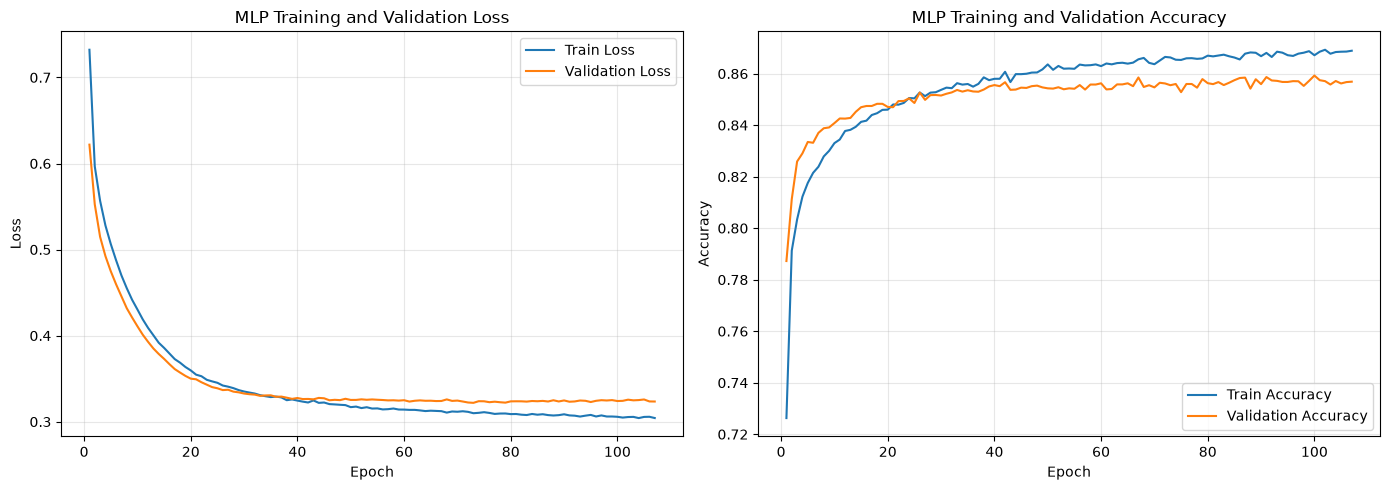

In [54]:
# Accuracy / Loss 그래프
import matplotlib.pyplot as plt

history_df = pd.DataFrame(
    selected_history.history
)

epochs = range(
    1,
    len(history_df) + 1
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Loss 그래프
axes[0].plot(
    epochs,
    history_df["loss"],
    label="Train Loss"
)

axes[0].plot(
    epochs,
    history_df["val_loss"],
    label="Validation Loss"
)

axes[0].set_title("MLP Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy 그래프
axes[1].plot(
    epochs,
    history_df["accuracy"],
    label="Train Accuracy"
)

axes[1].plot(
    epochs,
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

axes[1].set_title("MLP Training and Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

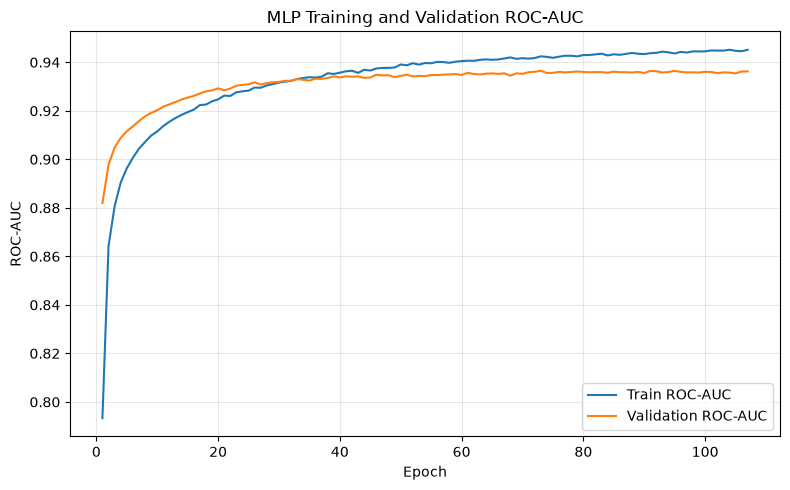

In [55]:
# ROC-AUC 그래프
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history_df["roc_auc"],
    label="Train ROC-AUC"
)

plt.plot(
    epochs,
    history_df["val_roc_auc"],
    label="Validation ROC-AUC"
)

plt.title("MLP Training and Validation ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
best_loss_epoch = (
    history_df["val_loss"].idxmin() + 1
)

best_accuracy_epoch = (
    history_df["val_accuracy"].idxmax() + 1
)

best_auc_epoch = (
    history_df["val_roc_auc"].idxmax() + 1
)

print(
    "Validation Loss 최소 Epoch:",
    best_loss_epoch,
    "|",
    history_df.loc[
        best_loss_epoch - 1,
        "val_loss"
    ]
)

print(
    "Validation Accuracy 최고 Epoch:",
    best_accuracy_epoch,
    "|",
    history_df.loc[
        best_accuracy_epoch - 1,
        "val_accuracy"
    ]
)

print(
    "Validation ROC-AUC 최고 Epoch:",
    best_auc_epoch,
    "|",
    history_df.loc[
        best_auc_epoch - 1,
        "val_roc_auc"
    ]
)

Validation Loss 최소 Epoch: 73 | 0.32192179560661316
Validation Accuracy 최고 Epoch: 100 | 0.8592514395713806
Validation ROC-AUC 최고 Epoch: 73 | 0.9364886283874512


In [58]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Validation 취소확률 예측
selected_val_proba = selected_mlp_val.predict(
    X_val_dl,
    batch_size=2048,
    verbose=0
).ravel()

# 기본 임계값 0.5 적용
default_threshold = 0.5

selected_val_pred_05 = (
    selected_val_proba >= default_threshold
).astype(int)

# 평가 결과
mlp_default_metrics = {
    "threshold": default_threshold,
    "accuracy": accuracy_score(
        y_val_dl,
        selected_val_pred_05
    ),
    "precision": precision_score(
        y_val_dl,
        selected_val_pred_05,
        zero_division=0
    ),
    "recall": recall_score(
        y_val_dl,
        selected_val_pred_05,
        zero_division=0
    ),
    "f1": f1_score(
        y_val_dl,
        selected_val_pred_05,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_val_dl,
        selected_val_proba
    )
}

print("MLP Validation 성능")
print("Threshold:", mlp_default_metrics["threshold"])
print(
    "Accuracy :",
    round(mlp_default_metrics["accuracy"], 4)
)
print(
    "Precision:",
    round(mlp_default_metrics["precision"], 4)
)
print(
    "Recall   :",
    round(mlp_default_metrics["recall"], 4)
)
print(
    "F1       :",
    round(mlp_default_metrics["f1"], 4)
)
print(
    "ROC-AUC  :",
    round(mlp_default_metrics["roc_auc"], 4)
)

print("\nConfusion Matrix")
print(
    confusion_matrix(
        y_val_dl,
        selected_val_pred_05
    )
)

MLP Validation 성능
Threshold: 0.5
Accuracy : 0.8569
Precision: 0.8183
Recall   : 0.7916
F1       : 0.8047
ROC-AUC  : 0.9363

Confusion Matrix
[[10660  1242]
 [ 1473  5595]]


In [59]:
import os
import pandas as pd
from sklearn.metrics import confusion_matrix

VALIDATION_DIR = "model_dl/validation"
os.makedirs(VALIDATION_DIR, exist_ok=True)

# 혼동행렬 값
tn, fp, fn, tp = confusion_matrix(
    y_val_dl,
    selected_val_pred_05
).ravel()

# 1. 평가 결과 저장
mlp_validation_result = pd.DataFrame([{
    "model": "Selected MLP",
    "data_split": "validation",
    "epochs": 107,
    "threshold": 0.5,
    "accuracy": mlp_default_metrics["accuracy"],
    "precision": mlp_default_metrics["precision"],
    "recall": mlp_default_metrics["recall"],
    "f1": mlp_default_metrics["f1"],
    "roc_auc": mlp_default_metrics["roc_auc"],
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "tp": tp
}])

mlp_validation_result.to_csv(
    f"{VALIDATION_DIR}/mlp_validation_threshold_05.csv",
    index=False,
    encoding="utf-8-sig"
)

# 2. 임계값 실험에 사용할 예측확률 저장
mlp_validation_predictions = pd.DataFrame({
    "y_true": np.asarray(y_val_dl).ravel(),
    "cancel_probability": selected_val_proba,
    "prediction_threshold_05": selected_val_pred_05
})

mlp_validation_predictions.to_csv(
    f"{VALIDATION_DIR}/mlp_validation_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

# 3. 107 Epoch 학습 기록 저장
history_df.to_csv(
    f"{VALIDATION_DIR}/mlp_validation_history.csv",
    index=False,
    encoding="utf-8-sig"
)

# 4. 현재 검증용 모델 저장
selected_mlp_val.save(
    f"{VALIDATION_DIR}/selected_mlp_validation_epoch107.keras"
)

print("저장 완료")
print(f"{VALIDATION_DIR}/mlp_validation_threshold_05.csv")
print(f"{VALIDATION_DIR}/mlp_validation_predictions.csv")
print(f"{VALIDATION_DIR}/mlp_validation_history.csv")
print(f"{VALIDATION_DIR}/selected_mlp_validation_epoch107.keras")

저장 완료
model_dl/validation/mlp_validation_threshold_05.csv
model_dl/validation/mlp_validation_predictions.csv
model_dl/validation/mlp_validation_history.csv
model_dl/validation/selected_mlp_validation_epoch107.keras


In [60]:
import json
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

VALIDATION_DIR = "model_dl/validation"

# 저장된 Validation 예측 결과 불러오기
prediction_df = pd.read_csv(
    f"{VALIDATION_DIR}/mlp_validation_predictions.csv"
)

y_true = prediction_df["y_true"].to_numpy()
val_proba = prediction_df[
    "cancel_probability"
].to_numpy()

# 0.200~0.800, 0.001 간격
thresholds = np.round(
    np.arange(0.200, 0.801, 0.001),
    3
)

threshold_results = []

for threshold in thresholds:
    prediction = (
        val_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        prediction
    ).ravel()

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_true,
            prediction
        ),
        "precision": precision_score(
            y_true,
            prediction,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            prediction,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            prediction,
            zero_division=0
        ),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

mlp_threshold_df = pd.DataFrame(
    threshold_results
)

# 최고 Accuracy
max_accuracy = mlp_threshold_df[
    "accuracy"
].max()

# 최고 Accuracy가 같은 임계값이 여러 개면
# 기본 임계값 0.5와 가장 가까운 값 선택
best_candidates = mlp_threshold_df[
    np.isclose(
        mlp_threshold_df["accuracy"],
        max_accuracy
    )
].copy()

best_candidates["distance_from_05"] = (
    best_candidates["threshold"] - 0.5
).abs()

mlp_best_result = (
    best_candidates
    .sort_values("distance_from_05")
    .iloc[0]
)

mlp_best_threshold = float(
    mlp_best_result["threshold"]
)

mlp_val_roc_auc = roc_auc_score(
    y_true,
    val_proba
)

print("MLP Accuracy 최적 임계값:", mlp_best_threshold)
print("Validation Accuracy :", round(mlp_best_result["accuracy"], 4))
print("Validation Precision:", round(mlp_best_result["precision"], 4))
print("Validation Recall   :", round(mlp_best_result["recall"], 4))
print("Validation F1       :", round(mlp_best_result["f1"], 4))
print("Validation ROC-AUC  :", round(mlp_val_roc_auc, 4))

print("\nConfusion Matrix")
print([
    [int(mlp_best_result["tn"]), int(mlp_best_result["fp"])],
    [int(mlp_best_result["fn"]), int(mlp_best_result["tp"])]
])

print("\nAccuracy 기준 상위 10개")
display(
    mlp_threshold_df
    .sort_values(
        ["accuracy", "f1"],
        ascending=[False, False]
    )
    .head(10)
)

MLP Accuracy 최적 임계값: 0.511
Validation Accuracy : 0.8572
Validation Precision: 0.8232
Validation Recall   : 0.7857
Validation F1       : 0.804
Validation ROC-AUC  : 0.9363

Confusion Matrix
[[10709, 1193], [1515, 5553]]

Accuracy 기준 상위 10개


,threshold,accuracy,precision,recall,f1,tn,fp,fn,tp
311,0.511,0.857248,0.823154,0.785654,0.803967,10709,1193,1515,5553
312,0.512,0.857196,0.823416,0.785088,0.803795,10712,1190,1519,5549
305,0.505,0.857090,0.820887,0.788483,0.804359,10686,1216,1495,5573
293,0.493,0.857037,0.815013,0.797255,0.806036,10623,1279,1433,5635
306,0.506,0.857037,0.821050,0.788059,0.804216,10688,1214,1498,5570
313,0.513,0.856985,0.823503,0.784239,0.803392,10714,1188,1525,5543
307,0.507,0.856932,0.821376,0.787210,0.803930,10692,1210,1504,5564
314,0.514,0.856932,0.824055,0.783248,0.803134,10720,1182,1532,5536
316,0.516,0.856932,0.824635,0.782400,0.802962,10726,1176,1538,5530
322,0.522,0.856932,0.827467,0.778297,0.802129,10755,1147,1567,5501


In [61]:
default_result = mlp_threshold_df[
    np.isclose(
        mlp_threshold_df["threshold"],
        0.5
    )
].iloc[0]

comparison_df = pd.DataFrame([
    {
        "type": "기본 임계값",
        **default_result.to_dict(),
        "roc_auc": mlp_val_roc_auc
    },
    {
        "type": "Accuracy 최적 임계값",
        **mlp_best_result.drop(
            labels=["distance_from_05"],
            errors="ignore"
        ).to_dict(),
        "roc_auc": mlp_val_roc_auc
    }
])

display(
    comparison_df[
        [
            "type",
            "threshold",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "tn",
            "fp",
            "fn",
            "tp"
        ]
    ]
)

,type,threshold,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,기본 임계값,0.500,0.856879,0.818341,0.791596,0.804746,0.936298,10660.0,1242.0,1473.0,5595.0
1,Accuracy 최적 임계값,0.511,0.857248,0.823154,0.785654,0.803967,0.936298,10709.0,1193.0,1515.0,5553.0


In [62]:
mlp_threshold_df.to_csv(
    f"{VALIDATION_DIR}/mlp_threshold_search.csv",
    index=False,
    encoding="utf-8-sig"
)

comparison_df.to_csv(
    f"{VALIDATION_DIR}/mlp_threshold_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

with open(
    f"{VALIDATION_DIR}/mlp_best_threshold.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        {
            "selection_metric": "validation_accuracy",
            "best_threshold": mlp_best_threshold,
            "validation_accuracy": float(
                mlp_best_result["accuracy"]
            ),
            "validation_roc_auc": float(
                mlp_val_roc_auc
            )
        },
        file,
        ensure_ascii=False,
        indent=2
    )

print("임계값 탐색 결과 저장 완료")

임계값 탐색 결과 저장 완료


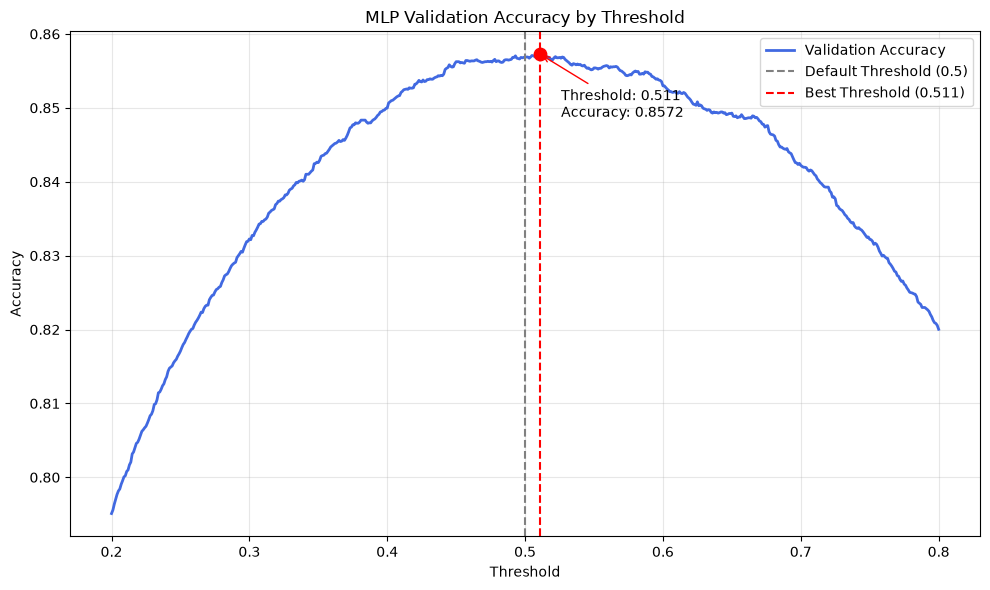

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 임계값별 Accuracy
plt.plot(
    mlp_threshold_df["threshold"],
    mlp_threshold_df["accuracy"],
    color="royalblue",
    linewidth=2,
    label="Validation Accuracy"
)

# 기본 임계값 0.5
plt.axvline(
    0.5,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Default Threshold (0.5)"
)

# Accuracy 최적 임계값
plt.axvline(
    mlp_best_threshold,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Best Threshold "
        f"({mlp_best_threshold:.3f})"
    )
)

# 최고점 표시
plt.scatter(
    mlp_best_threshold,
    mlp_best_result["accuracy"],
    color="red",
    s=80,
    zorder=3
)

plt.annotate(
    (
        f"Threshold: {mlp_best_threshold:.3f}\n"
        f"Accuracy: {mlp_best_result['accuracy']:.4f}"
    ),
    xy=(
        mlp_best_threshold,
        mlp_best_result["accuracy"]
    ),
    xytext=(15, -45),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->",
        "color": "red"
    }
)

plt.title("MLP Validation Accuracy by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

# 발표자료용 이미지 저장
plt.savefig(
    f"{VALIDATION_DIR}/mlp_threshold_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

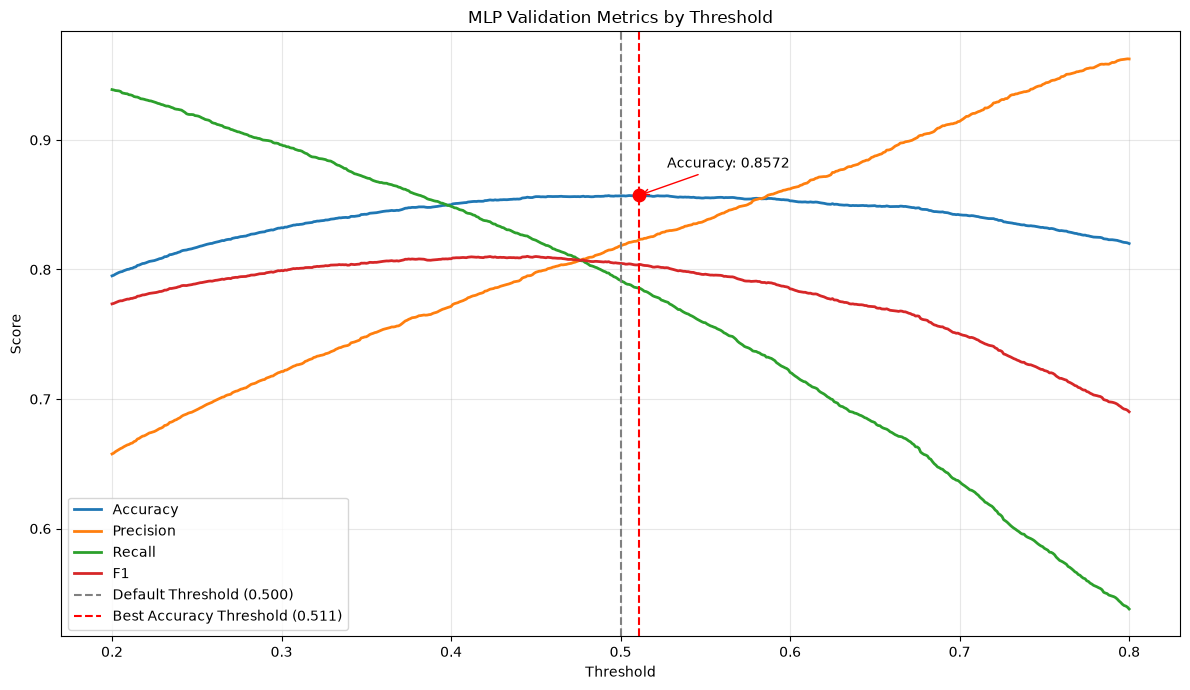

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.plot(
    mlp_threshold_df["threshold"],
    mlp_threshold_df["accuracy"],
    label="Accuracy",
    linewidth=2
)

plt.plot(
    mlp_threshold_df["threshold"],
    mlp_threshold_df["precision"],
    label="Precision",
    linewidth=2
)

plt.plot(
    mlp_threshold_df["threshold"],
    mlp_threshold_df["recall"],
    label="Recall",
    linewidth=2
)

plt.plot(
    mlp_threshold_df["threshold"],
    mlp_threshold_df["f1"],
    label="F1",
    linewidth=2
)

# 기본 임계값
plt.axvline(
    0.5,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Default Threshold (0.500)"
)

# Accuracy 최적 임계값
plt.axvline(
    mlp_best_threshold,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Best Accuracy Threshold "
        f"({mlp_best_threshold:.3f})"
    )
)

# 최적 Accuracy 지점
plt.scatter(
    mlp_best_threshold,
    mlp_best_result["accuracy"],
    color="red",
    s=80,
    zorder=3
)

plt.annotate(
    (
        f"Accuracy: "
        f"{mlp_best_result['accuracy']:.4f}"
    ),
    xy=(
        mlp_best_threshold,
        mlp_best_result["accuracy"]
    ),
    xytext=(20, 20),
    textcoords="offset points",
    arrowprops={
        "arrowstyle": "->",
        "color": "red"
    }
)

plt.title(
    "MLP Validation Metrics by Threshold"
)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{VALIDATION_DIR}/mlp_threshold_all_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [66]:
import os
import json
import time
import random
import joblib

import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.base import clone

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import (
    Dense,
    BatchNormalization,
    Dropout
)
from tensorflow.keras.regularizers import l2

FINAL_DIR = "model_dl/final"
os.makedirs(FINAL_DIR, exist_ok=True)

FINAL_EPOCHS = 107
DEFAULT_THRESHOLD = 0.5
OPTIMIZED_THRESHOLD = float(
    mlp_best_threshold
)

print("최종 Epoch:", FINAL_EPOCHS)
print("기본 임계값:", DEFAULT_THRESHOLD)
print("Accuracy 최적 임계값:", OPTIMIZED_THRESHOLD)

최종 Epoch: 107
기본 임계값: 0.5
Accuracy 최적 임계값: 0.511


In [67]:
# 기존 전처리기 구조를 복제
# clone()은 학습된 정보를 가져오지 않고 구조만 복제
preprocessor_final = clone(
    preprocessor
)

# 전체 X_train으로 전처리기 학습
X_train_final = preprocessor_final.fit_transform(
    X_train
).astype("float32")

# 최종 평가를 위한 X_test 변환
# X_test로 전처리기를 학습하지는 않음
X_test_final = preprocessor_final.transform(
    X_test
).astype("float32")

y_train_final = y_train.to_numpy(
    dtype="float32"
)

y_test_final = y_test.to_numpy(
    dtype="float32"
)

print("Final Train:", X_train_final.shape)
print("Final Test :", X_test_final.shape)
print("Train Target:", y_train_final.shape)
print("Test Target :", y_test_final.shape)

Final Train: (94848, 64)
Final Test : (23712, 64)
Train Target: (94848,)
Test Target : (23712,)


In [68]:
FINAL_PREPROCESSOR_PATH = (
    f"{FINAL_DIR}/final_mlp_preprocessor.joblib"
)

joblib.dump(
    preprocessor_final,
    FINAL_PREPROCESSOR_PATH
)

print(
    "최종 전처리기 저장:",
    FINAL_PREPROCESSOR_PATH
)

최종 전처리기 저장: model_dl/final/final_mlp_preprocessor.joblib


In [69]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

tf.keras.backend.clear_session()

final_mlp = Sequential([
    Input(shape=(X_train_final.shape[1],)),

    Dense(
        256,
        activation="relu",
        kernel_regularizer=l2(0.0005)
    ),
    BatchNormalization(),
    Dropout(0.4),

    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(0.0005)
    ),
    BatchNormalization(),
    Dropout(0.4),

    Dense(
        64,
        activation="relu",
        kernel_regularizer=l2(0.0005)
    ),
    BatchNormalization(),
    Dropout(0.4),

    Dense(
        1,
        activation="sigmoid"
    )
])

final_mlp.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),
        tf.keras.metrics.AUC(
            name="roc_auc"
        ),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

final_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,649 (233.00 KB)

 Trainable params: 58,753 (229.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [70]:
start_time = time.perf_counter()

final_history = final_mlp.fit(
    X_train_final,
    y_train_final,
    epochs=FINAL_EPOCHS,
    batch_size=512,
    shuffle=True,
    verbose=1
)

final_training_seconds = (
    time.perf_counter() - start_time
)

print(
    "최종 MLP 학습 시간:",
    round(
        final_training_seconds / 60,
        2
    ),
    "분"
)

Epoch 1/107
186/186 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7367 - loss: 0.7104 - precision: 0.6455 - recall: 0.6508 - roc_auc: 0.8051
Epoch 2/107
186/186 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7988 - loss: 0.5809 - precision: 0.7684 - recall: 0.6583 - roc_auc: 0.8710
Epoch 3/107
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8080 - loss: 0.5399 - precision: 0.7838 - recall: 0.6693 - roc_auc: 0.8858
Epoch 4/107
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8160 - loss: 0.5120 - precision: 0.7940 - recall: 0.6834 - roc_auc: 0.8939
Epoch 5/107
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8202 - loss: 0.4873 - precision: 0.7970 - recall: 0.6942 - roc_auc: 0.8997
Epoch 6/107
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8251 - loss: 0.4659 - precision: 0.8025 - recall: 0.7039 - roc_auc: 0.9046
Epoch 7/107
186/186 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8270 - loss: 0.4486 - precision: 0.8018 - recall: 0.7117 - roc_auc: 0.9074
Ep

In [71]:
FINAL_MODEL_PATH = (
    f"{FINAL_DIR}/final_mlp.keras"
)

FINAL_HISTORY_PATH = (
    f"{FINAL_DIR}/final_mlp_history.csv"
)

FINAL_CONFIG_PATH = (
    f"{FINAL_DIR}/final_mlp_config.json"
)

# 최종 모델 저장
final_mlp.save(
    FINAL_MODEL_PATH
)

# 학습 기록 저장
final_history_df = pd.DataFrame(
    final_history.history
)

final_history_df.insert(
    0,
    "epoch",
    np.arange(
        1,
        len(final_history_df) + 1
    )
)

final_history_df.to_csv(
    FINAL_HISTORY_PATH,
    index=False,
    encoding="utf-8-sig"
)

# 설정 및 임계값 저장
final_config = {
    "model_type": "MLP Binary Classifier",
    "units": [256, 128, 64],
    "hidden_activation": "relu",
    "output_activation": "sigmoid",
    "optimizer": "Adam",
    "learning_rate": 0.0005,
    "dropout": 0.4,
    "l2": 0.0005,
    "batch_size": 512,
    "batch_norm": True,
    "final_epochs": FINAL_EPOCHS,
    "input_features": int(
        X_train_final.shape[1]
    ),
    "default_threshold": DEFAULT_THRESHOLD,
    "optimized_threshold": OPTIMIZED_THRESHOLD,
    "threshold_selection_metric": (
        "validation_accuracy"
    ),
    "final_training_seconds": float(
        final_training_seconds
    )
}

with open(
    FINAL_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        final_config,
        file,
        ensure_ascii=False,
        indent=2
    )

print("최종 저장 완료")
print(FINAL_MODEL_PATH)
print(FINAL_PREPROCESSOR_PATH)
print(FINAL_HISTORY_PATH)
print(FINAL_CONFIG_PATH)

최종 저장 완료
model_dl/final/final_mlp.keras
model_dl/final/final_mlp_preprocessor.joblib
model_dl/final/final_mlp_history.csv
model_dl/final/final_mlp_config.json


In [72]:
import json
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

FINAL_DIR = "model_dl/final"

# 저장된 전처리기 불러오기
loaded_final_preprocessor = joblib.load(
    f"{FINAL_DIR}/final_mlp_preprocessor.joblib"
)

# 저장된 최종 모델 불러오기
loaded_final_mlp = tf.keras.models.load_model(
    f"{FINAL_DIR}/final_mlp.keras"
)

# 저장된 설정 불러오기
with open(
    f"{FINAL_DIR}/final_mlp_config.json",
    "r",
    encoding="utf-8"
) as file:
    loaded_final_config = json.load(file)

default_threshold = float(
    loaded_final_config["default_threshold"]
)

optimized_threshold = float(
    loaded_final_config["optimized_threshold"]
)

print("기본 임계값:", default_threshold)
print("최적 임계값:", optimized_threshold)

기본 임계값: 0.5
최적 임계값: 0.511


In [73]:
# 저장된 전처리기를 이용한 Test 변환
X_test_loaded = loaded_final_preprocessor.transform(
    X_test
).astype("float32")

y_test_loaded = y_test.to_numpy(
    dtype="int32"
)

print("Test 입력 형태:", X_test_loaded.shape)

# 최종 Test 취소확률 예측
final_test_proba = loaded_final_mlp.predict(
    X_test_loaded,
    batch_size=2048,
    verbose=0
).ravel()

print(
    "예측확률 범위:",
    round(float(final_test_proba.min()), 4),
    "~",
    round(float(final_test_proba.max()), 4)
)

Test 입력 형태: (23712, 64)
예측확률 범위: 0.0 ~ 1.0


In [74]:
test_thresholds = [
    (
        "기본 임계값",
        default_threshold
    ),
    (
        "Validation Accuracy 최적 임계값",
        optimized_threshold
    )
]

test_results = []
test_predictions = {}

final_test_auc = roc_auc_score(
    y_test_loaded,
    final_test_proba
)

for threshold_type, threshold in test_thresholds:
    prediction = (
        final_test_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_loaded,
        prediction
    ).ravel()

    test_results.append({
        "model": "Final MLP",
        "threshold_type": threshold_type,
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_test_loaded,
            prediction
        ),
        "precision": precision_score(
            y_test_loaded,
            prediction,
            zero_division=0
        ),
        "recall": recall_score(
            y_test_loaded,
            prediction,
            zero_division=0
        ),
        "f1": f1_score(
            y_test_loaded,
            prediction,
            zero_division=0
        ),
        "roc_auc": final_test_auc,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    })

    test_predictions[
        f"prediction_threshold_{threshold:.3f}"
    ] = prediction

final_test_metrics_df = pd.DataFrame(
    test_results
)

display(final_test_metrics_df)

,model,threshold_type,threshold,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,Final MLP,기본 임계값,0.500,0.860619,0.820766,0.800792,0.810656,0.939349,13332,1545,1760,7075
1,Final MLP,Validation Accuracy 최적 임계값,0.511,0.861884,0.828683,0.793322,0.810617,0.939349,13428,1449,1826,7009


In [75]:
for _, result in final_test_metrics_df.iterrows():
    print(
        f"\n{result['threshold_type']} "
        f"(Threshold {result['threshold']:.3f})"
    )

    print([
        [
            int(result["tn"]),
            int(result["fp"])
        ],
        [
            int(result["fn"]),
            int(result["tp"])
        ]
    ])


기본 임계값 (Threshold 0.500)
[[13332, 1545], [1760, 7075]]

Validation Accuracy 최적 임계값 (Threshold 0.511)
[[13428, 1449], [1826, 7009]]


In [76]:
# 최종 Test 지표 저장
final_test_metrics_df.to_csv(
    f"{FINAL_DIR}/final_mlp_test_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

# Test 예측 결과 저장
final_test_predictions_df = pd.DataFrame({
    "y_true": y_test_loaded,
    "cancel_probability": final_test_proba,
    **test_predictions
})

final_test_predictions_df.to_csv(
    f"{FINAL_DIR}/final_mlp_test_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("최종 Test 평가 결과 저장 완료")
print(
    f"{FINAL_DIR}/final_mlp_test_metrics.csv"
)
print(
    f"{FINAL_DIR}/final_mlp_test_predictions.csv"
)

최종 Test 평가 결과 저장 완료
model_dl/final/final_mlp_test_metrics.csv
model_dl/final/final_mlp_test_predictions.csv


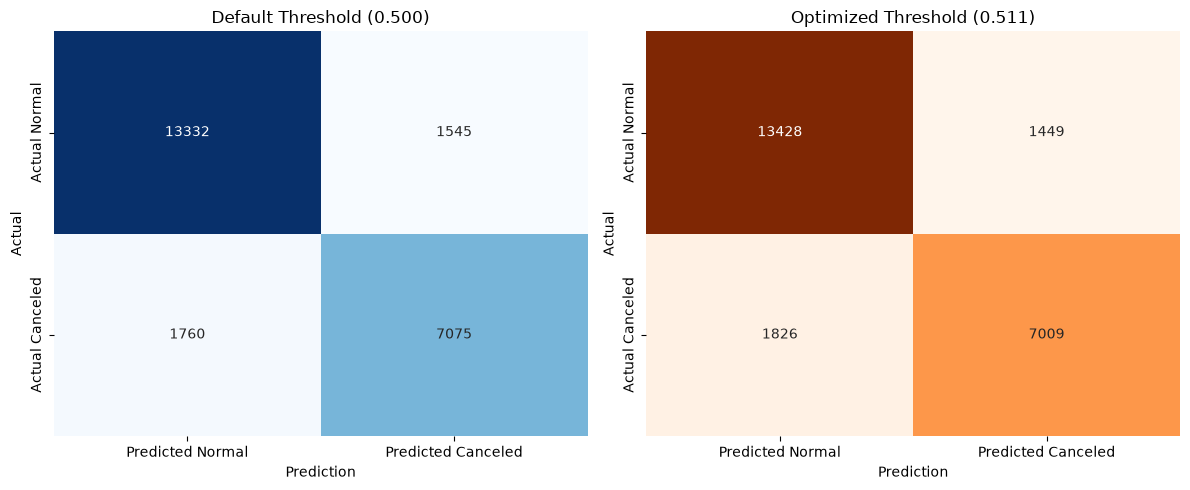

In [78]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

sns.heatmap(
    cm_default,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Predicted Normal",
        "Predicted Canceled"
    ],
    yticklabels=[
        "Actual Normal",
        "Actual Canceled"
    ],
    ax=axes[0]
)

axes[0].set_title(
    f"Default Threshold ({default_threshold:.3f})"
)
axes[0].set_xlabel("Prediction")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_optimized,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar=False,
    xticklabels=[
        "Predicted Normal",
        "Predicted Canceled"
    ],
    yticklabels=[
        "Actual Normal",
        "Actual Canceled"
    ],
    ax=axes[1]
)

axes[1].set_title(
    f"Optimized Threshold ({optimized_threshold:.3f})"
)
axes[1].set_xlabel("Prediction")
axes[1].set_ylabel("Actual")

plt.tight_layout()

plt.savefig(
    f"{FINAL_DIR}/final_mlp_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [1]:
import os

print("현재 작업 경로:")
print(os.getcwd())

rf_metrics_path = (
    "../ML_PRJ/model/evaluation/rf_test_metrics.csv"
)

print("\nRF 파일 존재 여부:")
print(os.path.exists(rf_metrics_path))

현재 작업 경로:
d:\pythonscript\Deep_Learning_PRJ

RF 파일 존재 여부:
True


In [2]:
import pandas as pd

# MLP 최종 Test 평가 결과
mlp_metrics = pd.read_csv(
    "model_dl/final/final_mlp_test_metrics.csv"
)

# Random Forest 최종 Test 평가 결과
rf_metrics = pd.read_csv(
    "../ML_PRJ/model/evaluation/rf_test_metrics.csv"
)

print("MLP 결과")
display(mlp_metrics.round(4))

print("Random Forest 결과")
display(rf_metrics.round(4))

MLP 결과


,model,threshold_type,threshold,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,Final MLP,기본 임계값,0.500,0.8606,0.8208,0.8008,0.8107,0.9393,13332,1545,1760,7075
1,Final MLP,Validation Accuracy 최적 임계값,0.511,0.8619,0.8287,0.7933,0.8106,0.9393,13428,1449,1826,7009


Random Forest 결과


,model,threshold_type,threshold,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,Moderate Random Forest,기본 임계값,0.5,0.8663,0.867,0.7573,0.8085,0.942,13852,1026,2144,6691


In [ ]:
# MLP 0.5 기본 임계값만 선택해서 비교

mlp_default = mlp_metrics[
    mlp_metrics["threshold"] == 0.5
].copy()

rf_default = rf_metrics[
    rf_metrics["threshold"] == 0.5
].copy()

model_comparison = pd.concat(
    [
        rf_default,
        mlp_default
    ],
    ignore_index=True
)

comparison_cols = [
    "model",
    "threshold",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "tn",
    "fp",
    "fn",
    "tp"
]

model_comparison = model_comparison[
    comparison_cols
]

display(
    model_comparison.round(4)
)

,model,threshold,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,Moderate Random Forest,0.5,0.8663,0.8670,0.7573,0.8085,0.9420,13852,1026,2144,6691
1,Final MLP,0.5,0.8606,0.8208,0.8008,0.8107,0.9393,13332,1545,1760,7075


In [ ]:
# RF vs MLP 임계값 0.5 비교표 저장

model_comparison.to_csv(
    "model_dl/final/rf_mlp_default_comparison.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "비교표 저장 완료:",
    "model_dl/final/rf_mlp_default_comparison.csv"
)

비교표 저장 완료: model_dl/final/rf_mlp_default_comparison.csv


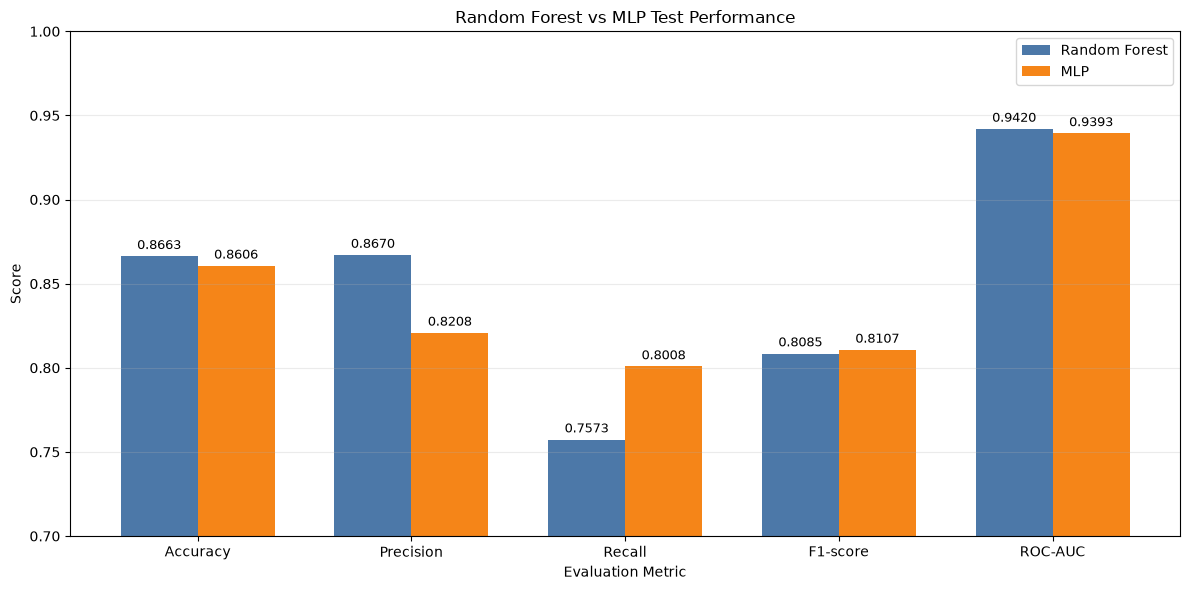

In [ ]:
# 성능 비교 그래프 시각화

import matplotlib.pyplot as plt
import numpy as np

metric_cols = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

metric_labels = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "ROC-AUC"
]

rf_scores = (
    model_comparison
    .loc[
        model_comparison["model"]
        == "Moderate Random Forest",
        metric_cols
    ]
    .iloc[0]
    .to_numpy(dtype=float)
)

mlp_scores = (
    model_comparison
    .loc[
        model_comparison["model"]
        == "Final MLP",
        metric_cols
    ]
    .iloc[0]
    .to_numpy(dtype=float)
)

x = np.arange(
    len(metric_cols)
)

width = 0.36

fig, ax = plt.subplots(
    figsize=(12, 6)
)

rf_bars = ax.bar(
    x - width / 2,
    rf_scores,
    width,
    label="Random Forest",
    color="#4C78A8"
)

mlp_bars = ax.bar(
    x + width / 2,
    mlp_scores,
    width,
    label="MLP",
    color="#F58518"
)

ax.set_title(
    "Random Forest vs MLP Test Performance"
)

ax.set_xlabel(
    "Evaluation Metric"
)

ax.set_ylabel(
    "Score"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    metric_labels
)

ax.set_ylim(
    0.70,
    1.0
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

ax.bar_label(
    rf_bars,
    fmt="%.4f",
    padding=3,
    fontsize=9
)

ax.bar_label(
    mlp_bars,
    fmt="%.4f",
    padding=3,
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "model_dl/final/rf_mlp_default_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

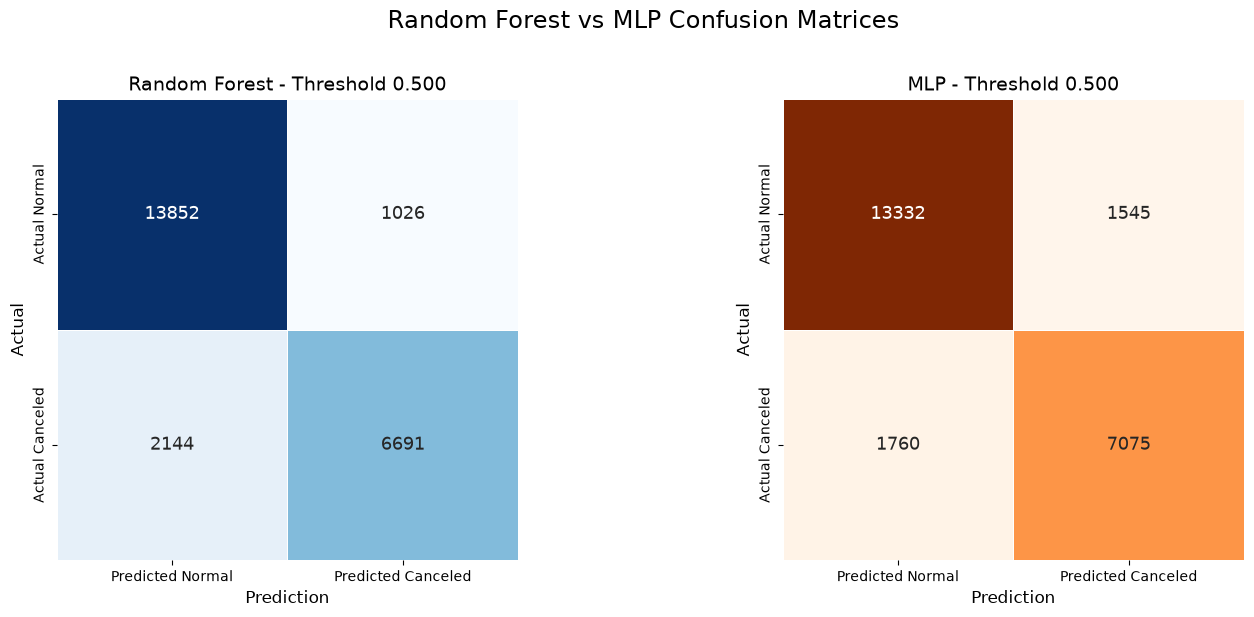

혼동행렬 저장 완료: model_dl/final/rf_mlp_confusion_matrices.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Random Forest 기본 임계값 결과
rf_row = model_comparison[
    model_comparison["model"]
    == "Moderate Random Forest"
].iloc[0]

# MLP 기본 임계값 결과
mlp_row = model_comparison[
    model_comparison["model"]
    == "Final MLP"
].iloc[0]

# 혼동행렬 구성
rf_cm = np.array([
    [
        int(rf_row["tn"]),
        int(rf_row["fp"])
    ],
    [
        int(rf_row["fn"]),
        int(rf_row["tp"])
    ]
])

mlp_cm = np.array([
    [
        int(mlp_row["tn"]),
        int(mlp_row["fp"])
    ],
    [
        int(mlp_row["fn"]),
        int(mlp_row["tp"])
    ]
])

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

# Random Forest 혼동행렬
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    square=True,
    annot_kws={"size": 13},
    ax=axes[0]
)

axes[0].set_title(
    "Random Forest - Threshold 0.500",
    fontsize=14
)

axes[0].set_xlabel(
    "Prediction",
    fontsize=12
)

axes[0].set_ylabel(
    "Actual",
    fontsize=12
)

axes[0].set_xticklabels([
    "Predicted Normal",
    "Predicted Canceled"
])

axes[0].set_yticklabels(
    [
        "Actual Normal",
        "Actual Canceled"
    ],
    rotation=90,
    va="center"
)

# MLP 혼동행렬
sns.heatmap(
    mlp_cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar=False,
    linewidths=0.5,
    square=True,
    annot_kws={"size": 13},
    ax=axes[1]
)

axes[1].set_title(
    "MLP - Threshold 0.500",
    fontsize=14
)

axes[1].set_xlabel(
    "Prediction",
    fontsize=12
)

axes[1].set_ylabel(
    "Actual",
    fontsize=12
)

axes[1].set_xticklabels([
    "Predicted Normal",
    "Predicted Canceled"
])

axes[1].set_yticklabels(
    [
        "Actual Normal",
        "Actual Canceled"
    ],
    rotation=90,
    va="center"
)

fig.suptitle(
    "Random Forest vs MLP Confusion Matrices",
    fontsize=17,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "model_dl/final/rf_mlp_confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "혼동행렬 저장 완료:",
    "model_dl/final/rf_mlp_confusion_matrices.png"
)

In [ ]:
# =============================

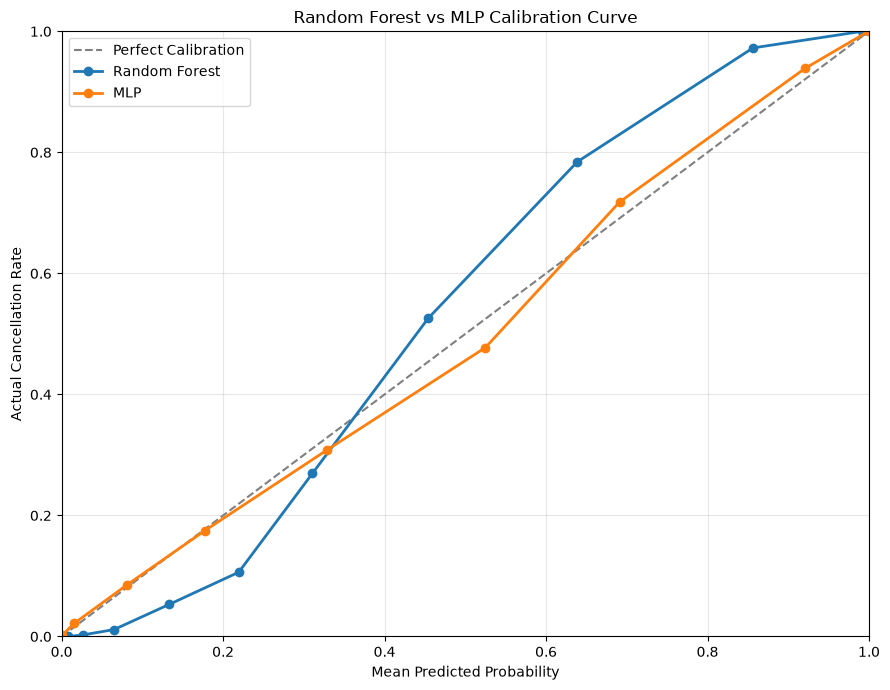

In [21]:
import matplotlib.pyplot as plt

from sklearn.calibration import (
    calibration_curve
)

rf_actual, rf_predicted = (
    calibration_curve(
        y_test,
        rf_test_probability,
        n_bins=10,
        strategy="quantile"
    )
)

mlp_actual, mlp_predicted = (
    calibration_curve(
        y_test,
        mlp_test_probability,
        n_bins=10,
        strategy="quantile"
    )
)

plt.figure(
    figsize=(9, 7)
)

# 완벽하게 보정된 기준선
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Perfect Calibration"
)

plt.plot(
    rf_predicted,
    rf_actual,
    marker="o",
    linewidth=2,
    label="Random Forest"
)

plt.plot(
    mlp_predicted,
    mlp_actual,
    marker="o",
    linewidth=2,
    label="MLP"
)

plt.title(
    "Random Forest vs MLP Calibration Curve"
)

plt.xlabel(
    "Mean Predicted Probability"
)

plt.ylabel(
    "Actual Cancellation Rate"
)

plt.xlim(
    0,
    1
)

plt.ylim(
    0,
    1
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "model_dl/final/"
    "rf_mlp_calibration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [3]:
import pandas as pd


categorical_cols = [
    "hotel",
    "arrival_date_month",
    "meal",
    "market_segment",
    "reserved_room_type",
    "customer_type",
    "country_group"
]


# 저장된 MLP 전처리기의 카테고리 확인
encoder = (
    mlp_preprocessor
    .named_transformers_["cat"]
    .named_steps["onehot"]
)


category_options = {
    column: list(categories)
    for column, categories in zip(
        categorical_cols,
        encoder.categories_
    )
}


# 현재 Streamlit 기본 입력 재현
streamlit_input = pd.DataFrame([{
    "hotel":
        category_options["hotel"][0],

    "arrival_date_month":
        category_options[
            "arrival_date_month"
        ][0],

    "meal":
        category_options["meal"][0],

    "market_segment":
        category_options[
            "market_segment"
        ][0],

    "reserved_room_type":
        category_options[
            "reserved_room_type"
        ][0],

    "customer_type":
        category_options[
            "customer_type"
        ][0],

    "country_group":
        category_options[
            "country_group"
        ][0],

    "lead_time": 30,
    "is_repeated_guest": 0,
    "previous_cancellations": 0,
    "previous_bookings_not_canceled": 0,
    "adr": 100.0,
    "required_car_parking_spaces": 0,
    "total_of_special_requests": 0,
    "has_agent": 0,
    "has_company": 0,
    "total_guests": 2,
    "total_nights": 2,
    "has_waiting_list": 0,
    "has_children": 0
}])


print(
    "Streamlit 기본 입력 생성 완료"
)

display(
    streamlit_input.T
)

Streamlit 기본 입력 생성 완료


,0
hotel,City Hotel
arrival_date_month,April
meal,BB
market_segment,Aviation
reserved_room_type,A
customer_type,Contract
country_group,BEL
lead_time,30
is_repeated_guest,0
previous_cancellations,0


In [23]:
import joblib
from pathlib import Path

split_path = Path(
    r"D:\pythonscript\Deep_Learning_PRJ"
    r"\model_dl\comparison"
    r"\common_data_split.joblib"
)

split_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "X_subtrain": X_subtrain,
        "X_val": X_val,
        "y_subtrain": y_subtrain,
        "y_val": y_val,
        "categorical_cols": categorical_cols,
        "numeric_cols": numeric_cols
    },
    split_path,
    compress=3
)

print(
    "공통 분할 데이터 저장 완료:",
    split_path
)

공통 분할 데이터 저장 완료: D:\pythonscript\Deep_Learning_PRJ\model_dl\comparison\common_data_split.joblib


In [24]:
import joblib
import pandas as pd
import tensorflow as tf


# 공통 분할 Random Forest가 메모리에 없으면 저장 파일에서 불러오기
if "rf_common_model" not in globals():

    rf_common_model = joblib.load(
        "../ML_PRJ/"
        "model_dl/comparison/"
        "rf_common_split.joblib"
    )

    print(
        "저장된 공통 Random Forest를 불러왔습니다."
    )


# MLP 전처리기가 메모리에 없으면 불러오기
if "mlp_preprocessor" not in globals():

    mlp_preprocessor = joblib.load(
        "model_dl/final/"
        "final_mlp_preprocessor.joblib"
    )

    print(
        "저장된 MLP 전처리기를 불러왔습니다."
    )


# MLP 모델이 메모리에 없으면 불러오기
if "mlp_model" not in globals():

    mlp_model = tf.keras.models.load_model(
        "model_dl/final/"
        "final_mlp.keras",
        compile=False
    )

    print(
        "저장된 MLP 모델을 불러왔습니다."
    )


# Streamlit 기본 입력 존재 여부 확인
if "streamlit_input" not in globals():

    raise RuntimeError(
        "streamlit_input이 없습니다. "
        "기본 입력 생성 코드를 먼저 실행하세요."
    )


# 같은 원본 입력을 Random Forest에 입력
rf_common_input_probability = float(
    rf_common_model.predict_proba(
        streamlit_input
    )[0, 1]
)


# 같은 원본 입력을 MLP 전처리기로 변환
mlp_input_processed = (
    mlp_preprocessor
    .transform(
        streamlit_input
    )
    .astype("float32")
)


# 전처리된 입력을 MLP에 입력
mlp_input_probability = float(
    mlp_model.predict(
        mlp_input_processed,
        verbose=0
    ).ravel()[0]
)


# 결과 비교
common_input_comparison = pd.DataFrame([
    {
        "model":
            "Random Forest",

        "cancel_probability":
            rf_common_input_probability,

        "cancel_probability_percent":
            rf_common_input_probability
            * 100
    },
    {
        "model":
            "MLP",

        "cancel_probability":
            mlp_input_probability,

        "cancel_probability_percent":
            mlp_input_probability
            * 100
    }
])

display(
    common_input_comparison
)

print(
    "MLP 입력 크기:",
    mlp_input_processed.shape
)

,model,cancel_probability,cancel_probability_percent
0,Random Forest,0.080755,8.075484
1,MLP,0.000021,0.002060


MLP 입력 크기: (1, 64)


In [25]:
from sklearn.neighbors import (
    NearestNeighbors
)

# MLP가 학습한 X_train을 동일하게 변환
X_train_processed = (
    mlp_preprocessor
    .transform(
        X_train
    )
    .astype("float32")
)

# Streamlit 입력은 이미 변환된 상태
query_processed = (
    mlp_input_processed
)

# 가장 유사한 예약 1,000건 탐색
neighbor_model = NearestNeighbors(
    n_neighbors=1000,
    metric="euclidean"
)

neighbor_model.fit(
    X_train_processed
)

distances, neighbor_positions = (
    neighbor_model.kneighbors(
        query_processed
    )
)

In [26]:
neighbor_summary = []

for neighbor_count in [
    50,
    100,
    300,
    500,
    1000
]:

    positions = (
        neighbor_positions[
            0,
            :neighbor_count
        ]
    )

    neighbor_targets = (
        y_train.iloc[
            positions
        ]
    )

    neighbor_summary.append({
        "유사 예약 수":
            neighbor_count,

        "실제 취소 건수":
            int(
                neighbor_targets.sum()
            ),

        "실제 정상 건수":
            int(
                neighbor_count
                - neighbor_targets.sum()
            ),

        "실제 취소율":
            neighbor_targets.mean(),

        "실제 취소율(%)":
            neighbor_targets.mean()
            * 100,

        "평균 거리":
            distances[
                0,
                :neighbor_count
            ].mean(),

        "최대 거리":
            distances[
                0,
                :neighbor_count
            ].max()
    })


neighbor_summary = pd.DataFrame(
    neighbor_summary
)

display(
    neighbor_summary.round(6)
)

,유사 예약 수,실제 취소 건수,실제 정상 건수,실제 취소율,실제 취소율(%),평균 거리,최대 거리
0,50,42,8,0.840000,84.000000,2.456718,2.490410
1,100,55,45,0.550000,55.000000,2.546778,2.821501
2,300,154,146,0.513333,51.333333,2.752531,2.870827
3,500,224,276,0.448000,44.800000,2.806231,2.913914
4,1000,404,596,0.404000,40.400000,2.922701,3.181855


In [27]:
categorical_match_mask = (
    X_train[categorical_cols]
    == streamlit_input.loc[
        0,
        categorical_cols
    ].to_numpy()
).all(
    axis=1
)

categorical_match_count = int(
    categorical_match_mask.sum()
)

print(
    "범주형 7개가 모두 같은 예약 수:",
    categorical_match_count
)

if categorical_match_count > 0:

    categorical_match_rate = (
        y_train.loc[
            categorical_match_mask
        ].mean()
    )

    print(
        "동일 범주 조합 실제 취소율:",
        f"{categorical_match_rate:.2%}"
    )

else:

    print(
        "동일 범주형 조합이 "
        "학습 데이터에 없습니다."
    )

범주형 7개가 모두 같은 예약 수: 0
동일 범주형 조합이 학습 데이터에 없습니다.


In [28]:
nearest_positions = (
    neighbor_positions[
        0,
        :20
    ]
)

nearest_rows = (
    X_train.iloc[
        nearest_positions
    ]
    .copy()
)

nearest_rows.insert(
    0,
    "distance",
    distances[
        0,
        :20
    ]
)

nearest_rows.insert(
    1,
    "actual_canceled",
    y_train.iloc[
        nearest_positions
    ].to_numpy()
)


# 가까운 예약에 대한 RF 확률
nearest_rows["rf_probability"] = (
    rf_common_model
    .predict_proba(
        X_train.iloc[
            nearest_positions
        ]
    )[:, 1]
)


# 가까운 예약에 대한 MLP 확률
nearest_processed = (
    mlp_preprocessor
    .transform(
        X_train.iloc[
            nearest_positions
        ]
    )
    .astype("float32")
)

nearest_rows["mlp_probability"] = (
    mlp_model.predict(
        nearest_processed,
        verbose=0
    ).ravel()
)


display(
    nearest_rows[
        [
            "distance",
            "actual_canceled",
            "rf_probability",
            "mlp_probability"
        ]
        + categorical_cols
        + [
            "lead_time",
            "adr",
            "total_nights",
            "total_guests",
            "previous_cancellations",
            "total_of_special_requests"
        ]
    ].round(6)
)

,distance,actual_canceled,rf_probability,mlp_probability,hotel,arrival_date_month,meal,market_segment,reserved_room_type,customer_type,country_group,lead_time,adr,total_nights,total_guests,previous_cancellations,total_of_special_requests
109830,2.110491,0,0.025139,0.000451,City Hotel,April,BB,Direct,A,Transient-Party,BEL,11,124.5,3,2,0,0
109829,2.110491,0,0.025139,0.000451,City Hotel,April,BB,Direct,A,Transient-Party,BEL,11,124.5,3,2,0,0
109731,2.385197,0,0.043009,0.002153,City Hotel,April,BB,Direct,A,Transient,BEL,8,148.0,4,2,0,0
109107,2.462949,0,0.182633,0.326982,City Hotel,April,BB,Direct,A,Transient,PRT,5,95.0,2,2,0,0
87216,2.465975,0,0.033870,0.008441,City Hotel,April,BB,Direct,A,Transient,Other,0,98.0,2,2,0,0
65530,2.468812,1,0.990231,0.998594,City Hotel,April,BB,Groups,A,Transient,PRT,54,110.0,2,2,0,0
65536,2.468812,1,0.990231,0.998594,City Hotel,April,BB,Groups,A,Transient,PRT,54,110.0,2,2,0,0
65545,2.468812,1,0.990231,0.998594,City Hotel,April,BB,Groups,A,Transient,PRT,54,110.0,2,2,0,0
65544,2.468812,1,0.990231,0.998594,City Hotel,April,BB,Groups,A,Transient,PRT,54,110.0,2,2,0,0
65527,2.468812,1,0.990231,0.998594,City Hotel,April,BB,Groups,A,Transient,PRT,54,110.0,2,2,0,0


In [29]:
rng = np.random.default_rng(
    42
)

sample_size = min(
    2000,
    len(X_train_processed)
)

sample_positions = rng.choice(
    len(X_train_processed),
    size=sample_size,
    replace=False
)

sample_distances, _ = (
    neighbor_model.kneighbors(
        X_train_processed[
            sample_positions
        ],
        n_neighbors=2
    )
)

# 첫 번째는 자기 자신이므로 두 번째 거리 사용
typical_nearest_distances = (
    sample_distances[:, 1]
)

print(
    "현재 입력의 가장 가까운 거리:",
    round(
        distances[0, 0],
        4
    )
)

print(
    "학습 데이터의 일반적인 최근접 거리"
)

print(
    "중앙값:",
    round(
        np.median(
            typical_nearest_distances
        ),
        4
    )
)

print(
    "90% 지점:",
    round(
        np.quantile(
            typical_nearest_distances,
            0.90
        ),
        4
    )
)

print(
    "95% 지점:",
    round(
        np.quantile(
            typical_nearest_distances,
            0.95
        ),
        4
    )
)

print(
    "99% 지점:",
    round(
        np.quantile(
            typical_nearest_distances,
            0.99
        ),
        4
    )
)

현재 입력의 가장 가까운 거리: 2.1105
학습 데이터의 일반적인 최근접 거리
중앙값: 0.2635
90% 지점: 1.4862
95% 지점: 1.7836
99% 지점: 2.2387


In [30]:
import numpy as np
import pandas as pd

# 범주형 변수의 최빈값
categorical_modes = {
    column: X_train[column].mode().iloc[0]
    for column in categorical_cols
}

# 수치형 변수의 중앙값
numeric_medians = {
    column: X_train[column].median()
    for column in numeric_cols
}

# 대표 프로필 생성
representative_profile = pd.DataFrame([{
    **categorical_modes,
    **numeric_medians
}])

display(
    representative_profile.T
)

,0
hotel,City Hotel
arrival_date_month,August
meal,BB
market_segment,Online TA
reserved_room_type,A
customer_type,Transient
country_group,PRT
lead_time,70.0
is_repeated_guest,0.0
previous_cancellations,0.0


In [31]:
# 대표 프로필 전처리
representative_processed = (
    mlp_preprocessor
    .transform(
        representative_profile
    )
    .astype("float32")
)

# 이미 생성된 X_train_processed 사용
representative_distances, \
representative_positions = (
    neighbor_model.kneighbors(
        representative_processed,
        n_neighbors=20
    )
)

# 중복 조건을 확인할 후보 20개
candidate_positions = (
    representative_positions[0]
)

representative_candidates = (
    X_train.iloc[
        candidate_positions
    ]
    .copy()
)

representative_candidates.insert(
    0,
    "distance",
    representative_distances[0]
)

display(
    representative_candidates
)

,distance,hotel,arrival_date_month,meal,market_segment,reserved_room_type,customer_type,country_group,lead_time,is_repeated_guest,...,previous_bookings_not_canceled,adr,required_car_parking_spaces,total_of_special_requests,has_agent,has_company,total_guests,total_nights,has_waiting_list,has_children
72681,0.313777,City Hotel,August,BB,Online TA,A,Transient,PRT,69,0,...,0,80.10,0,0,1,0,2,3,0,0
56137,0.350004,City Hotel,August,BB,Online TA,A,Transient,PRT,53,0,...,0,109.80,0,0,1,0,2,3,0,0
41586,0.503435,City Hotel,August,BB,Online TA,A,Transient,PRT,104,0,...,0,76.50,0,0,1,0,2,3,0,0
41033,0.610136,City Hotel,August,BB,Online TA,A,Transient,PRT,97,0,...,0,76.50,0,0,1,0,2,2,0,0
41427,0.665280,City Hotel,August,BB,Online TA,A,Transient,PRT,0,0,...,0,90.00,0,0,1,0,2,3,0,0
41680,0.665280,City Hotel,August,BB,Online TA,A,Transient,PRT,0,0,...,0,90.00,0,0,1,0,2,3,0,0
40801,0.769371,City Hotel,August,BB,Online TA,A,Transient,PRT,0,0,...,0,98.00,0,0,1,0,2,2,0,0
41051,0.820843,City Hotel,August,BB,Online TA,A,Transient,PRT,147,0,...,0,76.50,0,0,1,0,2,3,0,0
73154,0.859403,City Hotel,August,BB,Online TA,A,Transient,PRT,36,0,...,0,100.00,0,0,1,0,2,1,0,0
42018,0.892195,City Hotel,August,BB,Online TA,A,Transient,PRT,149,0,...,0,80.75,0,0,1,0,2,4,0,0


In [32]:
representative_position = (
    candidate_positions[0]
)

representative_input = (
    X_train.iloc[
        [representative_position]
    ]
    .copy()
)

representative_actual = int(
    y_train.iloc[
        representative_position
    ]
)

print(
    "대표 예약 원본 인덱스:",
    representative_input.index[0]
)

print(
    "대표 예약 실제 결과:",
    representative_actual
)

display(
    representative_input.T
)

대표 예약 원본 인덱스: 72681
대표 예약 실제 결과: 1


,72681
hotel,City Hotel
arrival_date_month,August
meal,BB
market_segment,Online TA
reserved_room_type,A
customer_type,Transient
country_group,PRT
lead_time,69
is_repeated_guest,0
previous_cancellations,0


In [33]:
# Random Forest
representative_rf_probability = float(
    rf_common_model.predict_proba(
        representative_input
    )[0, 1]
)

# MLP
representative_mlp_processed = (
    mlp_preprocessor
    .transform(
        representative_input
    )
    .astype("float32")
)

representative_mlp_probability = float(
    mlp_model.predict(
        representative_mlp_processed,
        verbose=0
    ).ravel()[0]
)

representative_comparison = pd.DataFrame([
    {
        "model":
            "Random Forest",

        "cancel_probability":
            representative_rf_probability,

        "cancel_probability_percent":
            representative_rf_probability
            * 100
    },
    {
        "model":
            "MLP",

        "cancel_probability":
            representative_mlp_probability,

        "cancel_probability_percent":
            representative_mlp_probability
            * 100
    }
])

display(
    representative_comparison
)

,model,cancel_probability,cancel_probability_percent
0,Random Forest,0.709931,70.993071
1,MLP,0.761150,76.115042


In [34]:
import json
from pathlib import Path

default_input_path = Path(
    "model_dl/final/"
    "streamlit_default_input.json"
)

default_input_data = (
    representative_input
    .iloc[0]
    .to_dict()
)

# NumPy 자료형을 JSON 저장 가능한 기본 자료형으로 변환
for key, value in default_input_data.items():

    if hasattr(
        value,
        "item"
    ):
        default_input_data[key] = (
            value.item()
        )

with open(
    default_input_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        default_input_data,
        file,
        ensure_ascii=False,
        indent=2
    )

print(
    "Streamlit 대표 입력 저장 완료:",
    default_input_path
)

print(
    json.dumps(
        default_input_data,
        ensure_ascii=False,
        indent=2
    )
)

Streamlit 대표 입력 저장 완료: model_dl\final\streamlit_default_input.json
{
  "hotel": "City Hotel",
  "arrival_date_month": "August",
  "meal": "BB",
  "market_segment": "Online TA",
  "reserved_room_type": "A",
  "customer_type": "Transient",
  "country_group": "PRT",
  "lead_time": 69,
  "is_repeated_guest": 0,
  "previous_cancellations": 0,
  "previous_bookings_not_canceled": 0,
  "adr": 80.1,
  "required_car_parking_spaces": 0,
  "total_of_special_requests": 0,
  "has_agent": 1,
  "has_company": 0,
  "total_guests": 2,
  "total_nights": 3,
  "has_waiting_list": 0,
  "has_children": 0
}


In [35]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# 프로젝트 경로
DL_DIR = Path(r"D:\pythonscript\Deep_Learning_PRJ")
ML_DIR = Path(r"D:\pythonscript\ML_PRJ")

OUTPUT_DIR = DL_DIR / "model_dl/comparison/verified_test"

# 1. 저장된 공통 분할 불러오기
split_data = joblib.load(
    DL_DIR / "model_dl/comparison/common_data_split.joblib"
)

X_test_common = split_data["X_test"]
y_test_common = split_data["y_test"]

# 특성과 정답의 행 순서 확인
assert X_test_common.index.equals(y_test_common.index), (
    "X_test와 y_test의 인덱스 또는 순서가 다릅니다."
)

assert X_test_common.index.is_unique, (
    "Test 인덱스가 중복되어 예약별 대조가 불가능합니다."
)

y_true = y_test_common.to_numpy().ravel()

# 2. 공통 분할 RF의 저장된 예측 결과
rf_predictions = pd.read_csv(
    ML_DIR / "model_dl/comparison/rf_common_test_predictions.csv"
)

assert rf_predictions["original_index"].is_unique, (
    "RF 예측 파일의 예약 인덱스가 중복되어 있습니다."
)

rf_indexed = rf_predictions.set_index("original_index")

assert (
    len(rf_indexed) == len(X_test_common)
    and X_test_common.index.isin(rf_indexed.index).all()
), "RF 예측 파일과 공통 Test의 예약 구성이 다릅니다."

# 같은 예약 순서로 정렬
rf_aligned = rf_indexed.loc[X_test_common.index]

np.testing.assert_array_equal(
    rf_aligned["y_true"].to_numpy(),
    y_true,
    err_msg="RF 예측 파일의 정답이 공통 Test와 다릅니다."
)

rf_probability = rf_aligned["cancel_probability"].to_numpy()

# 3. 저장된 최종 MLP와 전처리기 불러오기
mlp_preprocessor_check = joblib.load(
    DL_DIR / "model_dl/final/final_mlp_preprocessor.joblib"
)

mlp_model_check = tf.keras.models.load_model(
    DL_DIR / "model_dl/final/final_mlp.keras",
    compile=False
)

# fit 또는 fit_transform은 사용하지 않음
X_test_processed = mlp_preprocessor_check.transform(
    X_test_common
).astype("float32")

mlp_probability = mlp_model_check.predict(
    X_test_processed,
    batch_size=1024,
    verbose=0
).ravel()

# 4. 기존 MLP Test 예측과 대조
old_mlp_predictions = pd.read_csv(
    DL_DIR / "model_dl/final/final_mlp_test_predictions.csv"
)

np.testing.assert_array_equal(
    old_mlp_predictions["y_true"].to_numpy(),
    y_true,
    err_msg="기존 MLP Test 정답 또는 행 순서가 다릅니다."
)

old_mlp_probability = (
    old_mlp_predictions["cancel_probability"].to_numpy()
)

np.testing.assert_allclose(
    mlp_probability,
    old_mlp_probability,
    rtol=1e-5,
    atol=1e-6,
    err_msg=(
        "공통 Test에서 다시 예측한 MLP 확률이 기존 결과와 다릅니다. "
        "모델·전처리기·데이터 버전을 확인해야 합니다."
    )
)

print("RF 예약 인덱스·정답 대조: 통과")
print("MLP 정답·재예측 확률 대조: 통과")
print("공통 Test 예약 수:", len(y_true))
print(
    "MLP 기존 확률과의 최대 차이:",
    np.max(np.abs(mlp_probability - old_mlp_probability))
)

# 5. 두 모델을 동일한 임계값 0.5로 평가
probabilities = {
    "Random Forest": rf_probability,
    "MLP": mlp_probability
}

comparison_rows = []

for model_name, probability in probabilities.items():
    prediction = (probability >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        prediction,
        labels=[0, 1]
    ).ravel()

    comparison_rows.append({
        "model": model_name,
        "data_split": "Common Test",
        "n_samples": len(y_true),
        "threshold": 0.5,
        "accuracy": accuracy_score(y_true, prediction),
        "precision": precision_score(
            y_true, prediction, zero_division=0
        ),
        "recall": recall_score(
            y_true, prediction, zero_division=0
        ),
        "f1": f1_score(
            y_true, prediction, zero_division=0
        ),
        "roc_auc": roc_auc_score(y_true, probability),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    })

comparison_df = pd.DataFrame(comparison_rows)

# 예약 ID까지 포함한 통합 예측 파일
common_predictions_df = pd.DataFrame({
    "original_index": X_test_common.index.to_numpy(),
    "y_true": y_true,
    "rf_probability": rf_probability,
    "mlp_probability": mlp_probability,
    "adr": X_test_common["adr"].to_numpy(),
    "total_nights": X_test_common["total_nights"].to_numpy()
})

# 모든 검증이 통과한 경우에만 저장
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

comparison_df.to_csv(
    OUTPUT_DIR / "rf_mlp_common_test_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

common_predictions_df.to_csv(
    OUTPUT_DIR / "rf_mlp_common_test_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

display(comparison_df.round(4))
print("저장 위치:", OUTPUT_DIR)

RF 예약 인덱스·정답 대조: 통과
MLP 정답·재예측 확률 대조: 통과
공통 Test 예약 수: 23712
MLP 기존 확률과의 최대 차이: 1.336761474846071e-07


,model,data_split,n_samples,threshold,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,Random Forest,Common Test,23712,0.5,0.8671,0.8648,0.7624,0.8104,0.9426,13824,1053,2099,6736
1,MLP,Common Test,23712,0.5,0.8606,0.8208,0.8008,0.8107,0.9393,13332,1545,1760,7075


저장 위치: D:\pythonscript\Deep_Learning_PRJ\model_dl\comparison\verified_test


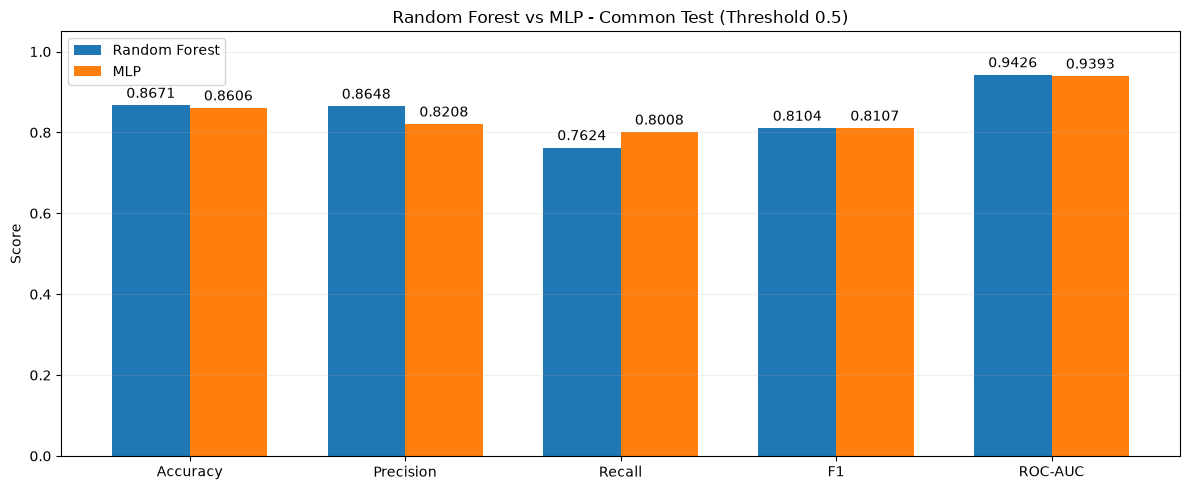

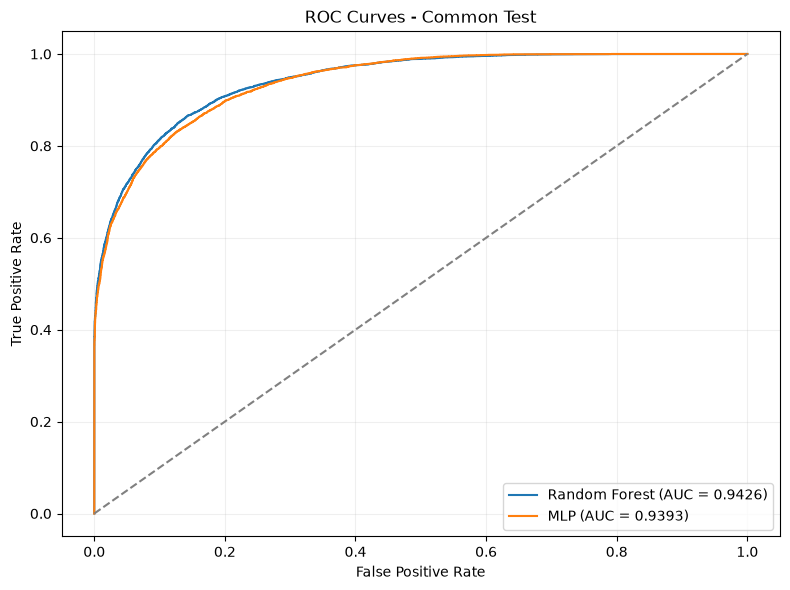

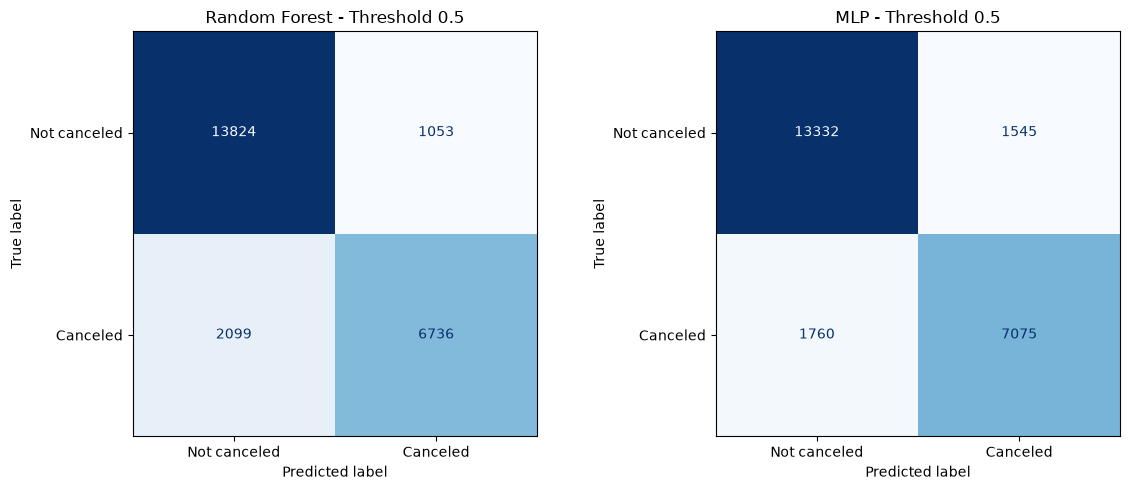

비교 그래프 3개 저장 완료: D:\pythonscript\Deep_Learning_PRJ\model_dl\comparison\verified_test


In [36]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    ConfusionMatrixDisplay
)

# 1. Test 성능 비교 막대그래프
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
labels = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

x = np.arange(len(metrics))
width = 0.36

fig, ax = plt.subplots(figsize=(12, 5))

for i, model_name in enumerate(["Random Forest", "MLP"]):
    values = (
        comparison_df.set_index("model")
        .loc[model_name, metrics]
        .to_numpy(dtype=float)
    )

    bars = ax.bar(
        x + (i - 0.5) * width,
        values,
        width,
        label=model_name
    )

    ax.bar_label(bars, fmt="%.4f", padding=3)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Random Forest vs MLP - Common Test (Threshold 0.5)")
ax.legend()
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "rf_mlp_common_test_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

# 2. ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, probability in probabilities.items():
    fpr, tpr, _ = roc_curve(y_true, probability)
    auc_value = roc_auc_score(y_true, probability)

    ax.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_value:.4f})"
    )

ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - Common Test")
ax.legend(loc="lower right")
ax.grid(alpha=0.2)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "rf_mlp_common_test_roc.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

# 3. 혼동행렬
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (model_name, probability) in zip(
    axes, probabilities.items()
):
    prediction = (probability >= 0.5).astype(int)

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        prediction,
        labels=[0, 1],
        display_labels=["Not canceled", "Canceled"],
        cmap="Blues",
        colorbar=False,
        values_format="d",
        ax=ax
    )

    ax.set_title(f"{model_name} - Threshold 0.5")

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "rf_mlp_common_test_confusion.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

print("비교 그래프 3개 저장 완료:", OUTPUT_DIR)

In [37]:
from pathlib import Path
from datetime import datetime
import time

import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

DL_DIR = Path(r"D:\pythonscript\Deep_Learning_PRJ")

# 실행마다 새 폴더를 만들어 기존 결과 보호
baseline_run_dir = (
    DL_DIR
    / "model_dl/baseline_recovery"
    / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
)
baseline_run_dir.mkdir(parents=True, exist_ok=False)

# 저장된 분할 복원: Test는 이번 학습·평가에 사용하지 않음
baseline_split = joblib.load(
    DL_DIR / "model_dl/comparison/common_data_split.joblib"
)

baseline_X_train = baseline_split["X_subtrain"]
baseline_X_val = baseline_split["X_val"]
baseline_y_train = baseline_split["y_subtrain"]
baseline_y_val = baseline_split["y_val"]

assert baseline_X_train.index.equals(baseline_y_train.index)
assert baseline_X_val.index.equals(baseline_y_val.index)

assert baseline_X_train.index.intersection(
    baseline_X_val.index
).empty, "Sub-train과 Validation의 예약 인덱스가 겹칩니다."

# 기존과 동일한 전처리 구조
baseline_preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("scaler", StandardScaler())
        ]),
        baseline_split["numeric_cols"]
    ),
    (
        "cat",
        Pipeline([
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]),
        baseline_split["categorical_cols"]
    )
])

# Sub-train에만 전처리기 학습
baseline_X_train_dl = (
    baseline_preprocessor
    .fit_transform(baseline_X_train)
    .astype("float32")
)

baseline_X_val_dl = (
    baseline_preprocessor
    .transform(baseline_X_val)
    .astype("float32")
)

baseline_y_train_dl = baseline_y_train.to_numpy(
    dtype="float32"
)
baseline_y_val_dl = baseline_y_val.to_numpy(
    dtype="float32"
)

joblib.dump(
    baseline_preprocessor,
    baseline_run_dir / "baseline_preprocessor.joblib"
)

# 새 모델 초기화
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

baseline_model = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(baseline_X_train_dl.shape[1],)
    ),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(32, activation="relu"),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="roc_auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# 기존 기본 MLP와 같은 콜백 조건
baseline_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        str(baseline_run_dir / "baseline_best.keras"),
        monitor="val_roc_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_roc_auc",
        mode="max",
        patience=12,
        min_delta=0.0002,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        str(baseline_run_dir / "baseline_history.csv")
    )
]

print("Sub-train:", baseline_X_train_dl.shape)
print("Validation:", baseline_X_val_dl.shape)
print("저장 폴더:", baseline_run_dir)

baseline_start = time.perf_counter()

baseline_history = baseline_model.fit(
    baseline_X_train_dl,
    baseline_y_train_dl,
    validation_data=(
        baseline_X_val_dl,
        baseline_y_val_dl
    ),
    epochs=100,
    batch_size=256,
    callbacks=baseline_callbacks,
    verbose=1
)

baseline_seconds = time.perf_counter() - baseline_start

print(f"기본 MLP 학습 완료: {baseline_seconds / 60:.2f}분")


Sub-train: (75878, 64)
Validation: (18970, 64)
저장 폴더: D:\pythonscript\Deep_Learning_PRJ\model_dl\baseline_recovery\20260901_154955_267749
Epoch 1/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7772 - loss: 0.4531 - precision: 0.7169 - recall: 0.6646 - roc_auc: 0.8523
Epoch 1: val_roc_auc improved from None to 0.90255, saving model to D:\pythonscript\Deep_Learning_PRJ\model_dl\baseline_recovery\20260901_154955_267749\baseline_best.keras

Epoch 1: finished saving model to D:\pythonscript\Deep_Learning_PRJ\model_dl\baseline_recovery\20260901_154955_267749\baseline_best.keras
297/297 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7772 - loss: 0.4531 - precision: 0.7169 - recall: 0.6646 - roc_auc: 0.8523 - val_accuracy: 0.8220 - val_loss: 0.3739 - val_precision: 0.8170 - val_recall: 0.6729 - val_roc_auc: 0.9025 - learning_rate: 0.0010
Epoch 2/100
291/297 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8175 - loss: 0.3787 - precision: 0.7904 - recall: 0.6941 - roc_auc: 0.8970
Epo

In [40]:
import json

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

baseline_best = tf.keras.models.load_model(
    baseline_run_dir / "baseline_best.keras",
    compile=False
)

baseline_val_probability = baseline_best.predict(
    baseline_X_val_dl,
    batch_size=1024,
    verbose=0
).ravel()

baseline_val_prediction = (
    baseline_val_probability >= 0.5
).astype(int)

baseline_log = pd.read_csv(
    baseline_run_dir / "baseline_history.csv"
)

baseline_best_row = baseline_log.loc[
    baseline_log["val_roc_auc"].idxmax()
]

baseline_best_epoch = int(
    baseline_best_row["epoch"]
) + 1

baseline_cm = confusion_matrix(
    baseline_y_val_dl,
    baseline_val_prediction,
    labels=[0, 1]
)

tn, fp, fn, tp = baseline_cm.ravel()

baseline_metrics = pd.DataFrame([{
    "model": "Baseline MLP - Re-run",
    "data_split": "Validation",
    "n_samples": len(baseline_y_val_dl),
    "threshold": 0.5,
    "epochs_run": len(baseline_log),
    "best_epoch": baseline_best_epoch,
    "training_seconds": baseline_seconds,
    "accuracy": accuracy_score(
        baseline_y_val_dl, baseline_val_prediction
    ),
    "precision": precision_score(
        baseline_y_val_dl,
        baseline_val_prediction,
        zero_division=0
    ),
    "recall": recall_score(
        baseline_y_val_dl,
        baseline_val_prediction,
        zero_division=0
    ),
    "f1": f1_score(
        baseline_y_val_dl,
        baseline_val_prediction,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        baseline_y_val_dl, baseline_val_probability
    ),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp)
}])

baseline_metrics.to_csv(
    baseline_run_dir / "baseline_validation_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

# 예약 인덱스까지 저장하여 추후 개선 MLP와 행별 대조 가능
pd.DataFrame({
    "original_index": baseline_X_val.index.to_numpy(),
    "y_true": baseline_y_val_dl.astype(int),
    "cancel_probability": baseline_val_probability,
    "prediction_threshold_0.500": baseline_val_prediction
}).to_csv(
    baseline_run_dir / "baseline_validation_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

# 실험 재현에 필요한 주요 설정 기록
baseline_config = {
    "experiment": "Baseline MLP re-run",
    "split_source": str(
        DL_DIR / "model_dl/comparison/common_data_split.joblib"
    ),
    "seed": 42,
    "units": [128, 64, 32],
    "hidden_activation": "relu",
    "output_activation": "sigmoid",
    "batch_norm_after_hidden_layers": [1, 2],
    "dropout_after_hidden_layers": [0.3, 0.2, 0.0],
    "l2": 0.0,
    "optimizer": "Adam",
    "learning_rate": 0.001,
    "batch_size": 256,
    "max_epochs": 100,
    "loss": "binary_crossentropy",
    "checkpoint_monitor": "val_roc_auc",
    "early_stopping_patience": 12,
    "early_stopping_min_delta": 0.0002,
    "reduce_lr_monitor": "val_loss",
    "reduce_lr_patience": 5,
    "reduce_lr_factor": 0.5,
    "min_learning_rate": 0.00001,
    "threshold": 0.5,
    "tensorflow_version": tf.__version__
}

with open(
    baseline_run_dir / "baseline_config.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        baseline_config,
        file,
        ensure_ascii=False,
        indent=2
    )

print("전체 학습 Epoch:", len(baseline_log))
print("최고 체크포인트 Epoch:", baseline_best_epoch)

display(baseline_metrics.round(4))

print("Validation 혼동행렬:")
print(baseline_cm)

print("\n저장 완료:", baseline_run_dir)

전체 학습 Epoch: 59
최고 체크포인트 Epoch: 55


,model,data_split,n_samples,threshold,epochs_run,best_epoch,training_seconds,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,Baseline MLP - Re-run,Validation,18970,0.5,59,55,78.2986,0.8562,0.8166,0.7919,0.8041,0.9359,10645,1257,1471,5597


Validation 혼동행렬:
[[10645  1257]
 [ 1471  5597]]

저장 완료: D:\pythonscript\Deep_Learning_PRJ\model_dl\baseline_recovery\20260901_154955_267749


In [ ]:
from pathlib import Path
import shutil

# 이번 재학습 결과가 저장된 폴더
if "baseline_run_dir" not in globals():
    raise RuntimeError(
        "baseline_run_dir이 없습니다. "
        "이번 재학습 결과 폴더 경로를 먼저 지정하세요."
    )

source_dir = Path(baseline_run_dir)
target_dir = source_dir.parent.parent  # model_dl

# 이번 결과 → 공식 기본 MLP 파일
file_mapping = {
    "baseline_best.keras":
        "mlp_baseline_best.keras",

    "baseline_preprocessor.joblib":
        "mlp_baseline_preprocessor.joblib",

    "baseline_history.csv":
        "mlp_baseline_log.csv",

    "baseline_validation_metrics.csv":
        "mlp_baseline_validation_metrics.csv",

    "baseline_validation_predictions.csv":
        "mlp_baseline_validation_predictions.csv",

    "baseline_config.json":
        "mlp_baseline_config.json",
}

# 필요한 파일이 모두 있는지 먼저 확인
missing_files = [
    name for name in file_mapping
    if not (source_dir / name).is_file()
]

if missing_files:
    raise FileNotFoundError(
        f"아직 저장되지 않은 파일: {missing_files}\n"
        "학습과 평가·저장 셀을 모두 실행한 뒤 다시 실행하세요."
    )

# 기존 파일은 덮어쓰고, 없는 파일은 새로 생성
for source_name, target_name in file_mapping.items():
    shutil.copy2(
        source_dir / source_name,
        target_dir / target_name
    )
    print(f"교체 완료: {target_name}")

print("\n이번 재학습 결과를 공식 기본 MLP 자료로 반영했습니다.")
print("최종 MLP와 탐색·공통 Test 자료는 변경하지 않았습니다.")

,model,data_split,threshold,accuracy,precision,recall,f1,roc_auc
0,Baseline MLP,Validation,0.5,0.8562,0.8166,0.7919,0.8041,0.9359
1,Improved MLP,Validation,0.5,0.8569,0.8183,0.7916,0.8047,0.9363


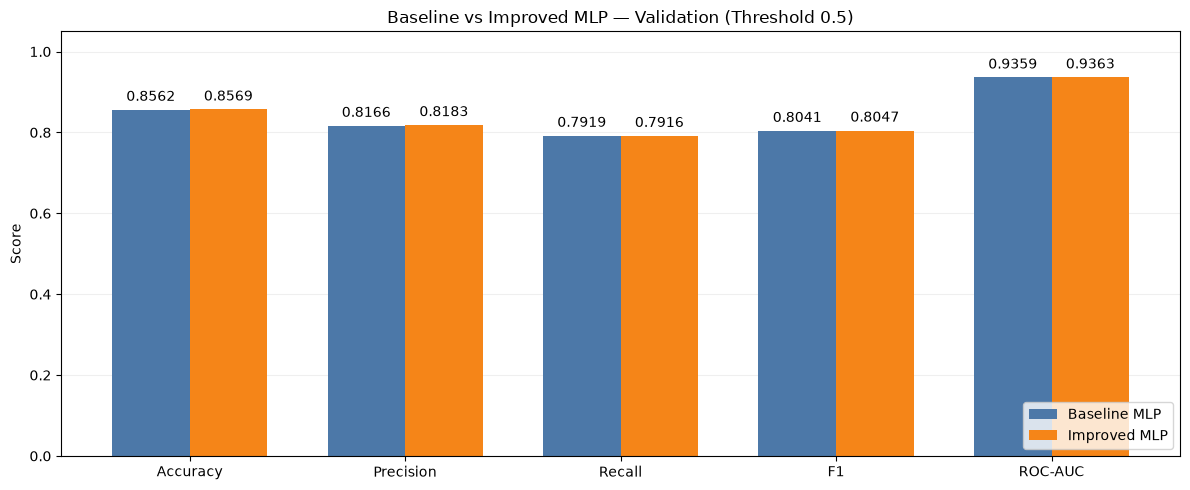

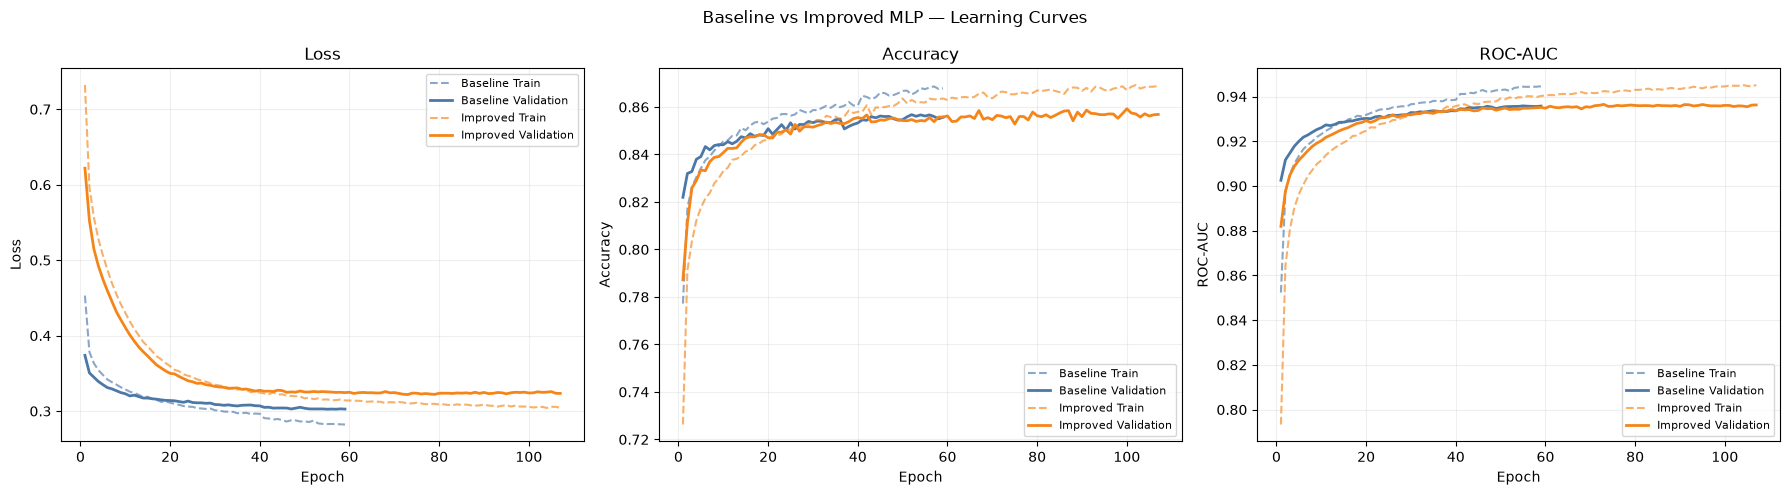

시각화 저장 위치: D:\pythonscript\Deep_Learning_PRJ\model_dl\comparison\baseline_vs_improved


In [45]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(r"D:\pythonscript\Deep_Learning_PRJ")
BASELINE_DIR = ROOT / "model_dl/baseline_recovery"
VALIDATION_DIR = ROOT / "model_dl/validation"
OUTPUT_DIR = ROOT / "model_dl/comparison/baseline_vs_improved"

# 필요한 파일 확인
files = {
    "baseline_metrics":
        BASELINE_DIR / "mlp_baseline_validation_metrics.csv",
    "baseline_history":
        BASELINE_DIR / "mlp_baseline_log.csv",
    "improved_metrics":
        VALIDATION_DIR / "mlp_validation_threshold_05.csv",
    "improved_history":
        VALIDATION_DIR / "mlp_validation_history.csv",
}

missing = [str(path) for path in files.values() if not path.is_file()]
if missing:
    raise FileNotFoundError("파일 위치를 확인하세요:\n" + "\n".join(missing))

baseline_metrics = pd.read_csv(files["baseline_metrics"])
improved_metrics = pd.read_csv(files["improved_metrics"])
baseline_history = pd.read_csv(files["baseline_history"])
improved_history = pd.read_csv(files["improved_history"])

# 임계값 0.5 결과만 선택
def select_default_result(df):
    selected = df.loc[np.isclose(df["threshold"], 0.5)]
    if len(selected) != 1:
        raise ValueError("임계값 0.5 결과가 정확히 한 행인지 확인하세요.")
    return selected.iloc[0]

baseline_row = select_default_result(baseline_metrics)
improved_row = select_default_result(improved_metrics)

metric_columns = [
    "accuracy", "precision", "recall", "f1", "roc_auc"
]
metric_labels = [
    "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"
]

comparison = pd.DataFrame([
    {
        "model": "Baseline MLP",
        "data_split": "Validation",
        "threshold": 0.5,
        **{key: float(baseline_row[key]) for key in metric_columns},
    },
    {
        "model": "Improved MLP",
        "data_split": "Validation",
        "threshold": 0.5,
        **{key: float(improved_row[key]) for key in metric_columns},
    },
])

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

comparison.to_csv(
    OUTPUT_DIR / "baseline_vs_improved_validation_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

display(comparison.round(4))

# ── 1. Validation 성능 비교 ──
x = np.arange(len(metric_columns))
width = 0.36
colors = ["#4C78A8", "#F58518"]

fig, ax = plt.subplots(figsize=(12, 5))

for i, model_name in enumerate(comparison["model"]):
    values = comparison.loc[i, metric_columns].to_numpy(dtype=float)

    bars = ax.bar(
        x + (i - 0.5) * width,
        values,
        width,
        label=model_name,
        color=colors[i]
    )
    ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title(
    "Baseline vs Improved MLP — Validation (Threshold 0.5)"
)
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "baseline_vs_improved_validation_metrics.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

# ── 2. 학습 곡선 비교 ──
# 두 CSV 모두 행 순서를 기준으로 Epoch를 1부터 표시
baseline_epochs = np.arange(1, len(baseline_history) + 1)
improved_epochs = np.arange(1, len(improved_history) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title in zip(
    axes,
    ["loss", "accuracy", "roc_auc"],
    ["Loss", "Accuracy", "ROC-AUC"]
):
    for history, epochs, label, color in [
        (baseline_history, baseline_epochs, "Baseline", colors[0]),
        (improved_history, improved_epochs, "Improved", colors[1]),
    ]:
        ax.plot(
            epochs, history[metric],
            color=color, linestyle="--", alpha=0.65,
            label=f"{label} Train"
        )
        ax.plot(
            epochs, history[f"val_{metric}"],
            color=color, linewidth=2,
            label=f"{label} Validation"
        )

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)

fig.suptitle("Baseline vs Improved MLP — Learning Curves")
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "baseline_vs_improved_learning_curves.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close(fig)

print("시각화 저장 위치:", OUTPUT_DIR)

In [47]:
import pandas as pd

capture = pd.read_csv(
    "model_dl/comparison/capture_analysis/"
    "mlp_validation_capture.csv"
)

selected = capture.loc[
    capture["target_review_share"].round(2).isin([0.25, 0.50]),
    [
        "target_review_share",
        "expected_loss_threshold",
        "n_review",
        "canceled_amount_capture_rate"
    ]
]

print(selected.to_string(index=False))

 target_review_share  expected_loss_threshold  n_review  canceled_amount_capture_rate
                0.25               198.637127      4743                      0.739950
                0.50                60.261749      9485                      0.958901


In [2]:
import joblib
import pandas as pd

split = joblib.load(
    "model_dl/comparison/common_data_split.joblib"
)

X_train = split["X_train"]
y_train = split["y_train"]

parking_check = pd.DataFrame({
    "parking": X_train["required_car_parking_spaces"],
    "is_canceled": y_train
})

result = (
    parking_check
    .groupby("parking")
    .agg(
        예약수=("is_canceled", "size"),
        취소건수=("is_canceled", "sum"),
        취소율=("is_canceled", "mean")
    )
)

result["취소율"] *= 100

print(result)

           예약수   취소건수        취소율
parking                         
0        88938  35339  39.734422
1         5882      0   0.000000
2           23      0   0.000000
3            3      0   0.000000
8            2      0   0.000000
